In [6]:
# Force white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
%matplotlib inline

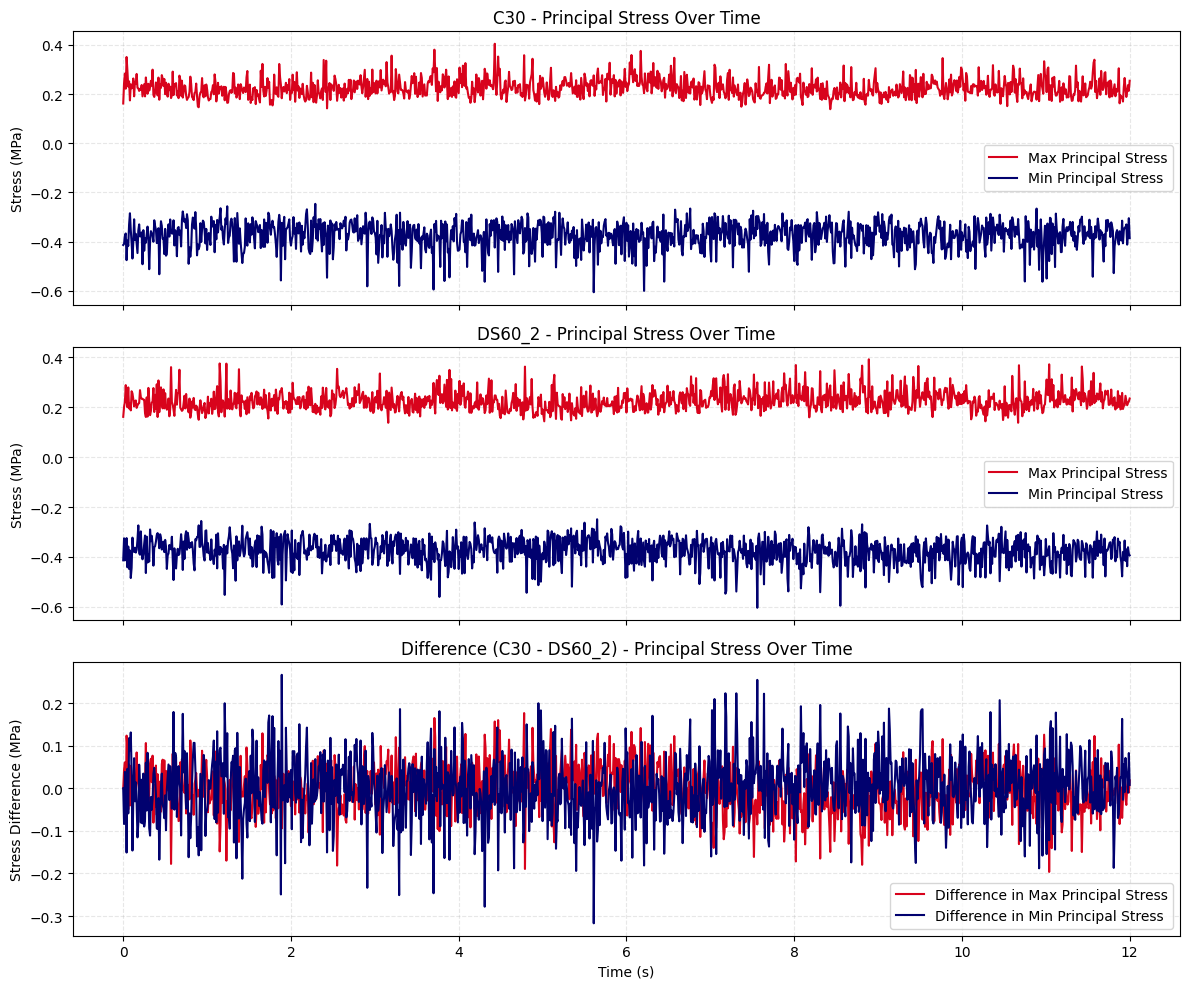

In [11]:
# CSV files
csv_C30 = 'principal_stress_per_block_Job-H-0_6_2300_30.csv'
csv_DS60 = 'principal_stress_per_block_Job-H-0_7_2300_30.csv'

# -------------------------------
# Load data
# -------------------------------

# Load both datasets
df_C30 = pd.read_csv(csv_C30)
df_DS60 = pd.read_csv(csv_DS60)

# Time vector
time = df_C30['Time']   # assume time vectors are identical

# Find min and max columns
cols_C30_max = [col for col in df_C30.columns if col.endswith('_max')]
cols_C30_min = [col for col in df_C30.columns if col.endswith('_min')]

cols_DS60_max = [col for col in df_DS60.columns if col.endswith('_max')]
cols_DS60_min = [col for col in df_DS60.columns if col.endswith('_min')]

# Compute max and min across blocks
max_C30 = df_C30[cols_C30_max].max(axis=1)
min_C30 = df_C30[cols_C30_min].min(axis=1)

max_DS60 = df_DS60[cols_DS60_max].max(axis=1)
min_DS60 = df_DS60[cols_DS60_min].min(axis=1)

# Compute differences
diff_max = max_C30 - max_DS60
diff_min = min_C30 - min_DS60

# --- Plotting ---
fig, axs = plt.subplots(
    3, 1,
    figsize=(12, 10),
    sharex=True,
    facecolor='white'     # this guarantees white background
)

# New color mapping
color_max = '#d8031c'  # red
color_min = '#01016f'  # blue

# --- Subplot 1: C30 ---
axs[0].plot(time, max_C30/1e6, color=color_max, label='Max Principal Stress')
axs[0].plot(time, min_C30/1e6, color=color_min, label='Min Principal Stress')
axs[0].set_title('C30 - Principal Stress Over Time')
axs[0].set_ylabel('Stress (MPa)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.3)

# --- Subplot 2: DS60_2 ---
axs[1].plot(time, max_DS60/1e6, color=color_max, label='Max Principal Stress')
axs[1].plot(time, min_DS60/1e6, color=color_min, label='Min Principal Stress')
axs[1].set_title('DS60_2 - Principal Stress Over Time')
axs[1].set_ylabel('Stress (MPa)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.3)

# --- Subplot 3: Difference (C30 - DS60_2) ---
axs[2].plot(time, diff_max/1e6, color=color_max, label='Difference in Max Principal Stress')
axs[2].plot(time, diff_min/1e6, color=color_min, label='Difference in Min Principal Stress')
axs[2].set_title('Difference (C30 - DS60_2) - Principal Stress Over Time')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Stress Difference (MPa)')
axs[2].legend()
axs[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# File path
# -------------------------------
csv_path = 'principal_stress_per_block_H05-2300_30.csv'

# -------------------------------
# Load data
# -------------------------------
df = pd.read_csv(csv_path)

# Time vector
time = df['Time']

# Find all _max and _min columns
max_cols = [col for col in df.columns if col.endswith('_max')]
min_cols = [col for col in df.columns if col.endswith('_min')]

# Compute row-wise min and max across blocks
max_across_blocks = df[max_cols].max(axis=1)
min_across_blocks = df[min_cols].min(axis=1)

# -------------------------------
# Define wave windows
# -------------------------------
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]

# Compute subsequent wave starts
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

# Create list of (start, end) tuples for waves
wave_periods = [(start, start + wave_duration) for start in wave_starts]

# Create list of (start, end) tuples for rest periods
rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    if rest_start < time.max():
        rest_end = min(rest_end, time.max())
        rest_periods.append((rest_start, rest_end))

# -------------------------------
# Analyze waves and rest periods
# -------------------------------
results = []

for i, (wave_start, wave_end) in enumerate(wave_periods):
    # Wave period mask
    mask_wave = (time >= wave_start) & (time <= wave_end)

    # Extract wave data for all blocks
    wave_df_max = df.loc[mask_wave, max_cols]
    wave_df_min = df.loc[mask_wave, min_cols]

    # True max of max and min of min across all blocks and time
    max_max_wave = wave_df_max.values.max() / 1e6
    min_min_wave = wave_df_min.values.min() / 1e6

    # Corresponding rest period
    if i < len(rest_periods):
        rest_start, rest_end = rest_periods[i]
        mask_rest = (time > rest_start) & (time <= rest_end)

        rest_df_max = df.loc[mask_rest, max_cols]
        rest_df_min = df.loc[mask_rest, min_cols]

        avg_max_rest = rest_df_max.values.mean() / 1e6
        avg_min_rest = rest_df_min.values.mean() / 1e6
    else:
        rest_start, rest_end = None, None
        avg_max_rest, avg_min_rest = None, None

    results.append({
        'Wave': f"Wave {i+1}",
        'Wave Start (s)': wave_start,
        'Wave End (s)': wave_end,
        'Max of Max (MPa)': max_max_wave,
        'Min of Min (MPa)': min_min_wave,
        'Rest Start (s)': rest_start,
        'Rest End (s)': rest_end,
        'Avg Max during Rest (MPa)': avg_max_rest,
        'Avg Min during Rest (MPa)': avg_min_rest
    })

# -------------------------------
# Prepare table data
# -------------------------------
table_data = []
for res in results:
    wave_period = f"{res['Wave Start (s)']:.2f}-{res['Wave End (s)']:.2f}"
    max_max_str = f"{res['Max of Max (MPa)']:.3f}"
    min_min_str = f"{res['Min of Min (MPa)']:.3f}"

    if res['Rest Start (s)'] is not None:
        rest_period = f"{res['Rest Start (s)']:.2f}-{res['Rest End (s)']:.2f}"
        avg_max_rest_str = f"{res['Avg Max during Rest (MPa)']:.3f}"
        avg_min_rest_str = f"{res['Avg Min during Rest (MPa)']:.3f}"
    else:
        rest_period = "-"
        avg_max_rest_str = "-"
        avg_min_rest_str = "-"

    table_data.append([
        res['Wave'],
        wave_period,
        max_max_str,
        min_min_str,
        rest_period,
        avg_max_rest_str,
        avg_min_rest_str
    ])

columns = [
    "Wave",
    "Wave Period (s)",
    "Max of Max (MPa)",
    "Min of Min (MPa)",
    "Rest Period (s)",
    "Avg Max in Rest (MPa)",
    "Avg Min in Rest (MPa)"
]

# -------------------------------
# Plotting
# -------------------------------
fig, ax = plt.subplots(
    figsize=(14, 6),
    dpi=200,
    facecolor='white'   # Force white figure background
)

# Also force white axes background
ax.set_facecolor('white')

# Plot stress curves
ax.plot(
    time,
    min_across_blocks / 1e6,
    color='#d8031c',
    linewidth=1.5,
    label='Min Principal Stress (min across blocks)'
)

ax.plot(
    time,
    max_across_blocks / 1e6,
    color='#01016f',
    linewidth=1.5,
    label='Max Principal Stress (max across blocks)'
)

# Shade wave periods
for start, end in wave_periods:
    ax.axvspan(start, end, color='lightblue', alpha=0.4)
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# File path
# -------------------------------
csv_path = 'principal_stress_per_block_H05-2300_30.csv'

# -------------------------------
# Load data
# -------------------------------
df = pd.read_csv(csv_path)

# Time vector
time = df['Time']

# Find all _max and _min columns
max_cols = [col for col in df.columns if col.endswith('_max')]
min_cols = [col for col in df.columns if col.endswith('_min')]

# Compute row-wise min and max across blocks
max_across_blocks = df[max_cols].max(axis=1)
min_across_blocks = df[min_cols].min(axis=1)

# -------------------------------
# Define wave windows
# -------------------------------
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]

# Compute subsequent wave starts
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

# Create list of (start, end) tuples for waves
wave_periods = [(start, start + wave_duration) for start in wave_starts]

# Create list of (start, end) tuples for rest periods
rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    if rest_start < time.max():
        rest_end = min(rest_end, time.max())
        rest_periods.append((rest_start, rest_end))

# -------------------------------
# Analyze waves and rest periods
# -------------------------------
wave_centers = []
wave_max_vals = []
wave_min_vals = []

rest_centers = []
rest_avg_max_vals = []
rest_avg_min_vals = []

for i, (wave_start, wave_end) in enumerate(wave_periods):
    # Wave period mask
    mask_wave = (time >= wave_start) & (time <= wave_end)

    # Extract wave data for all blocks
    wave_df_max = df.loc[mask_wave, max_cols]
    wave_df_min = df.loc[mask_wave, min_cols]

    # True max of max and min of min across all blocks and time
    max_max_wave = wave_df_max.values.max() / 1e6
    min_min_wave = wave_df_min.values.min() / 1e6

    wave_center = (wave_start + wave_end) / 2
    wave_centers.append(wave_center)
    wave_max_vals.append(max_max_wave)
    wave_min_vals.append(min_min_wave)

    # Corresponding rest period
    if i < len(rest_periods):
        rest_start, rest_end = rest_periods[i]
        mask_rest = (time > rest_start) & (time <= rest_end)

        avg_max_rest = max_across_blocks[mask_rest].mean() / 1e6
        avg_min_rest = min_across_blocks[mask_rest].mean() / 1e6

        rest_center = (rest_start + rest_end) / 2
        rest_centers.append(rest_center)
        rest_avg_max_vals.append(avg_max_rest)
        rest_avg_min_vals.append(avg_min_rest)

# -------------------------------
# Plotting
# -------------------------------
fig, ax = plt.subplots(
    figsize=(14, 6),
    dpi=200,
    facecolor='white'
)

ax.set_facecolor('white')

# Plot stress curves
ax.plot(
    time,
    min_across_blocks / 1e6,
    color='#d8031c',
    linewidth=1.5,
    label='Min Principal Stress (min across blocks)'
)

ax.plot(
    time,
    max_across_blocks / 1e6,
    color='#01016f',
    linewidth=1.5,
    label='Max Principal Stress (max across blocks)'
)

# Shade wave periods
for start, end in wave_periods:
    ax.axvspan(start, end, color='lightblue', alpha=0.4)

# Shade rest periods
for start, end in rest_periods:
    ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# Plot wave dots
ax.scatter(
    wave_centers,
    wave_max_vals,
    color='#01016f',
    marker='o',
    s=60,
    label='Max of Max (Wave)'
)

ax.scatter(
    wave_centers,
    wave_min_vals,
    color='#d8031c',
    marker='o',
    s=60,
    label='Min of Min (Wave)'
)

# Plot rest averages
if rest_centers:
    ax.scatter(
        rest_centers,
        rest_avg_max_vals,
        color='#01016f',
        marker='s',
        s=60,
        label='Avg Max in Rest'
    )

    ax.scatter(
        rest_centers,
        rest_avg_min_vals,
        color='#d8031c',
        marker='s',
        s=60,
        label='Avg Min in Rest'
    )

# Labels and style
ax.set_title("Principal Stress Over Time with Wave and Rest Periods", fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Principal Stress (MPa)", fontsize=12)
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# Shade rest periods
for start, end in rest_periods:
    ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# Labels and style
ax.set_title("Principal Stress Over Time with Wave and Rest Periods", fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Principal Stress (MPa)", fontsize=12)
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# -------------------------------
# Console Output
# -------------------------------
print("\n--- Detailed Results ---")
for res in results:
    print(f"{res['Wave']}:")
    print(f"  Wave Period: {res['Wave Start (s)']:.2f}-{res['Wave End (s)']:.2f} s")
    print(f"     Max of Max: {res['Max of Max (MPa)']:.3f} MPa")
    print(f"     Min of Min: {res['Min of Min (MPa)']:.3f} MPa")
    if res['Rest Start (s)'] is not None:
        print(f"  Rest Period: {res['Rest Start (s)']:.2f}-{res['Rest End (s)']:.2f} s")
        print(f"     Avg Max in Rest: {res['Avg Max during Rest (MPa)']:.3f} MPa")
        print(f"     Avg Min in Rest: {res['Avg Min during Rest (MPa)']:.3f} MPa")
    print("")


FileNotFoundError: [Errno 2] No such file or directory: 'principal_stress_per_block_H05-2300_30.csv'

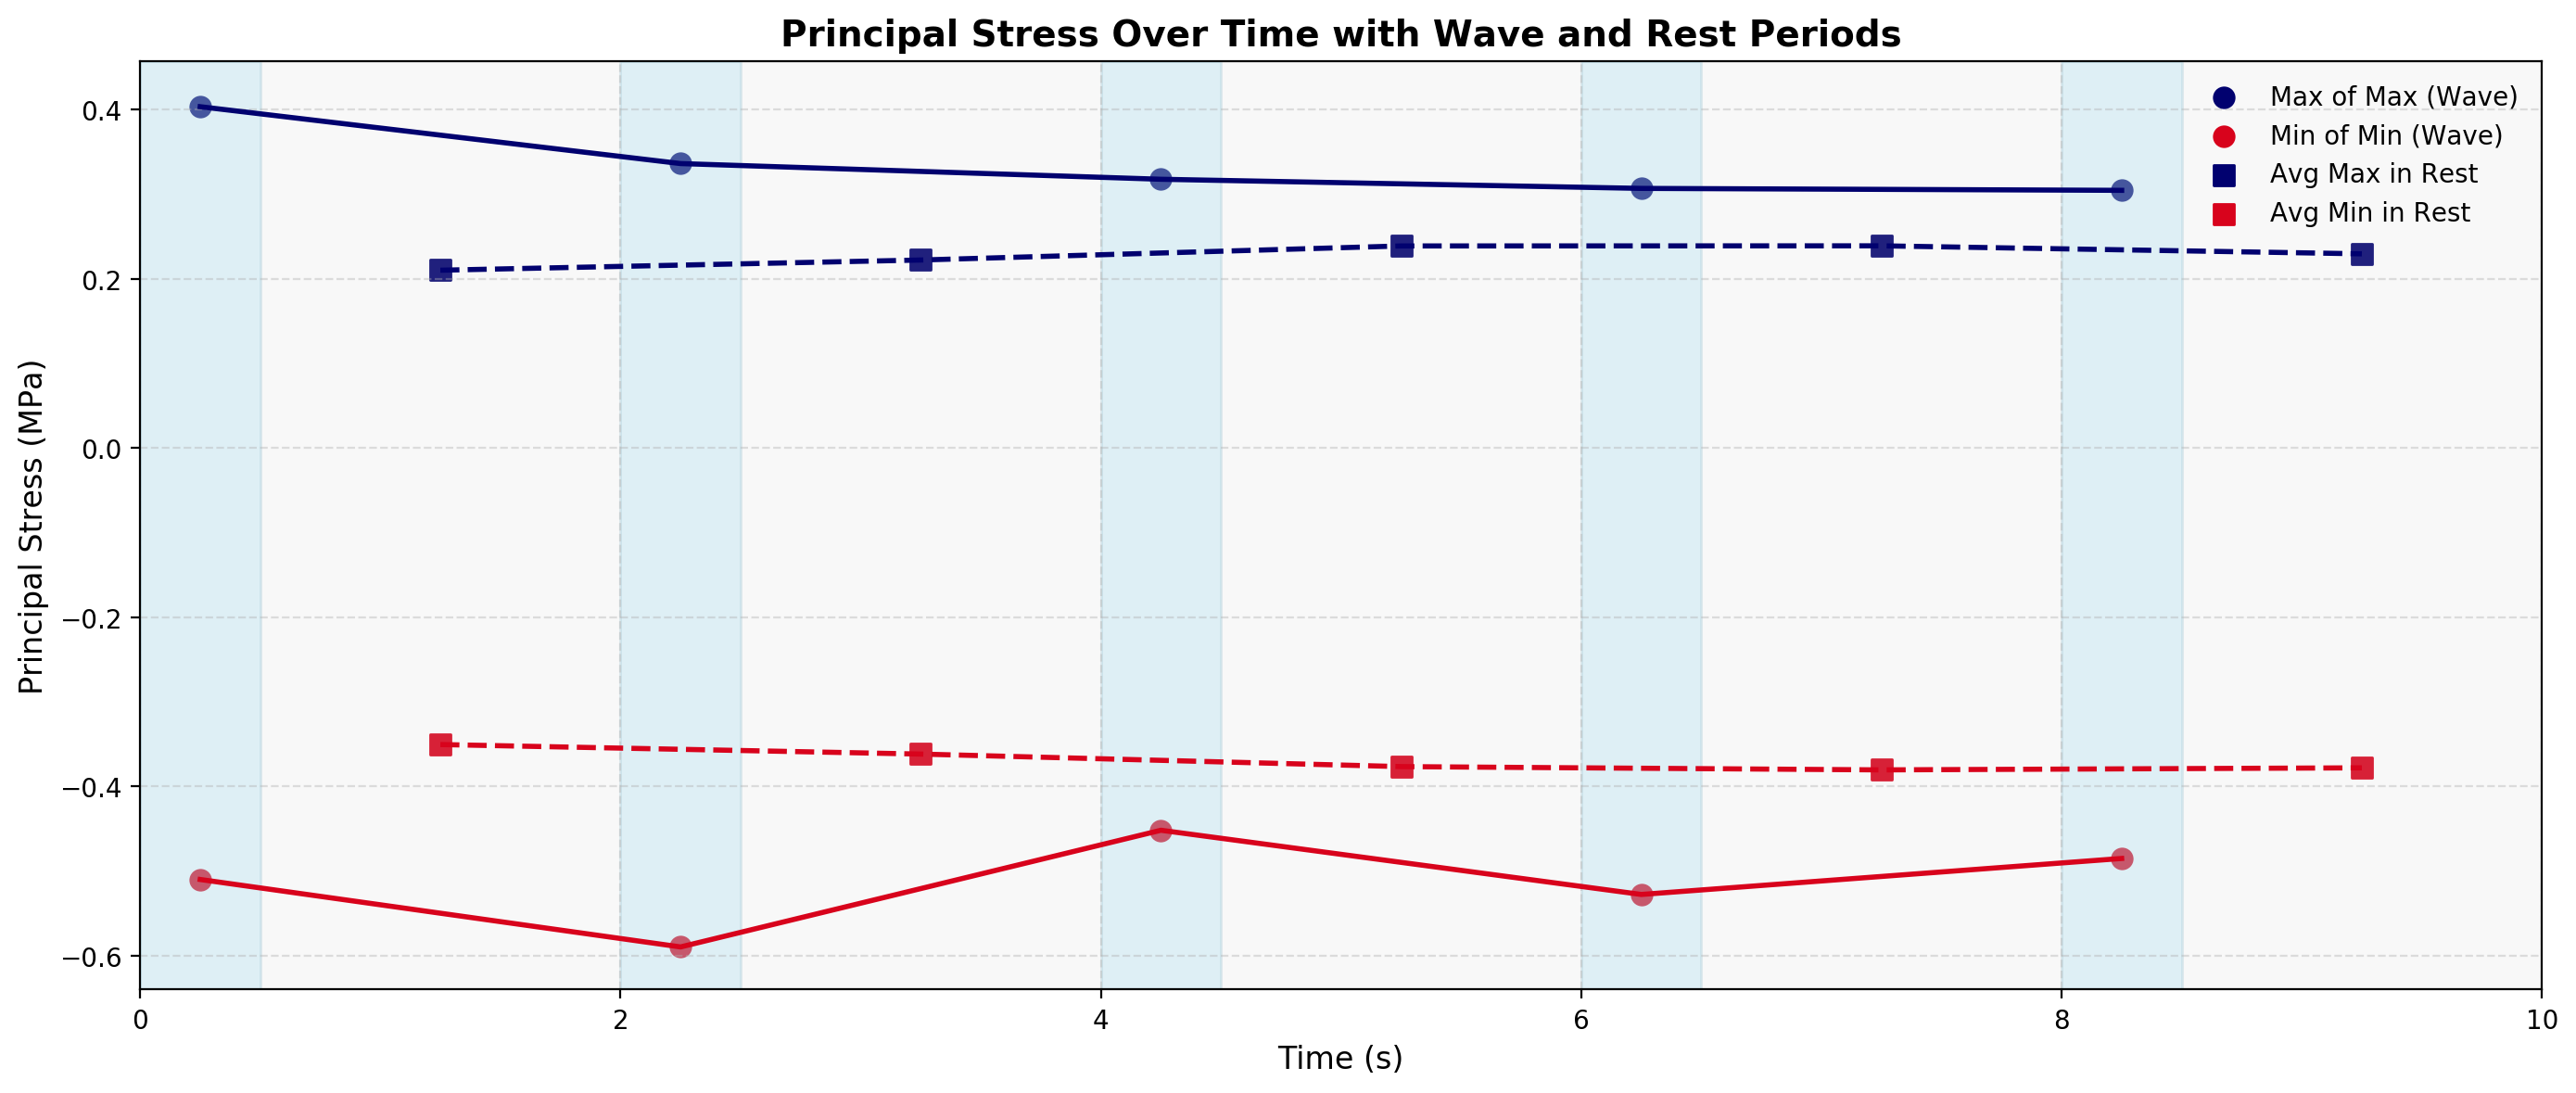

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# File path
# -------------------------------
csv_path = 'principal_stress_per_block_H05-2300_30.csv'

# -------------------------------
# Load data
# -------------------------------
df = pd.read_csv(csv_path)

# Time vector
time = df['Time']

# Find all _max and _min columns
max_cols = [col for col in df.columns if col.endswith('_max')]
min_cols = [col for col in df.columns if col.endswith('_min')]

# Compute row-wise min and max across blocks
max_across_blocks = df[max_cols].max(axis=1)
min_across_blocks = df[min_cols].min(axis=1)

# -------------------------------
# Define wave windows
# -------------------------------
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]

# Compute subsequent wave starts
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

# Create list of (start, end) tuples for waves
wave_periods = [(start, start + wave_duration) for start in wave_starts]

# Create list of (start, end) tuples for rest periods
rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    if rest_start < time.max():
        rest_end = min(rest_end, time.max())
        rest_periods.append((rest_start, rest_end))

# -------------------------------
# Analyze waves and rest periods
# -------------------------------
wave_centers = []
wave_max_vals = []
wave_min_vals = []

rest_centers = []
rest_avg_max_vals = []
rest_avg_min_vals = []

for i, (wave_start, wave_end) in enumerate(wave_periods):
    # Wave period mask
    mask_wave = (time >= wave_start) & (time <= wave_end)

    # Extract wave data for all blocks
    wave_df_max = df.loc[mask_wave, max_cols]
    wave_df_min = df.loc[mask_wave, min_cols]

    # True max of max and min of min across all blocks and time
    max_max_wave = wave_df_max.values.max() / 1e6
    min_min_wave = wave_df_min.values.min() / 1e6

    wave_center = (wave_start + wave_end) / 2
    wave_centers.append(wave_center)
    wave_max_vals.append(max_max_wave)
    wave_min_vals.append(min_min_wave)

    # Corresponding rest period
    if i < len(rest_periods):
        rest_start, rest_end = rest_periods[i]
        mask_rest = (time > rest_start) & (time <= rest_end)

        avg_max_rest = max_across_blocks[mask_rest].mean() / 1e6
        avg_min_rest = min_across_blocks[mask_rest].mean() / 1e6

        rest_center = (rest_start + rest_end) / 2
        rest_centers.append(rest_center)
        rest_avg_max_vals.append(avg_max_rest)
        rest_avg_min_vals.append(avg_min_rest)

# -------------------------------
# Plotting
# -------------------------------
fig, ax = plt.subplots(
    figsize=(14, 6),
    dpi=200,
    facecolor='white'
)

ax.set_facecolor('white')

# Plot stress curves
# ax.plot(
#     time,
#     min_across_blocks / 1e6,
#     color='#d8031c',
#     linewidth=1.5,
#     label='Min Principal Stress (min across blocks)'
# )

# ax.plot(
#     time,
#     max_across_blocks / 1e6,
#     color='#01016f',
#     linewidth=1.5,
#     label='Max Principal Stress (max across blocks)'
# )

# Shade wave periods
for start, end in wave_periods:
    ax.axvspan(start, end, color='lightblue', alpha=0.4)

# Shade rest periods
for start, end in rest_periods:
    ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# Plot wave dots
ax.scatter(
    wave_centers,
    wave_max_vals,
    color='#01016f',
    marker='o',
    s=60,
    label='Max of Max (Wave)'
)

ax.scatter(
    wave_centers,
    wave_min_vals,
    color='#d8031c',
    marker='o',
    s=60,
    label='Min of Min (Wave)'
)

# Plot lines through wave points
ax.plot(
    wave_centers,
    wave_max_vals,
    color='#01016f',
    linestyle='-',
    linewidth=2
)

ax.plot(
    wave_centers,
    wave_min_vals,
    color='#d8031c',
    linestyle='-',
    linewidth=2
)

# Plot rest averages
if rest_centers:
    ax.scatter(
        rest_centers,
        rest_avg_max_vals,
        color='#01016f',
        marker='s',
        s=60,
        label='Avg Max in Rest'
    )

    ax.scatter(
        rest_centers,
        rest_avg_min_vals,
        color='#d8031c',
        marker='s',
        s=60,
        label='Avg Min in Rest'
    )

    # Plot lines through rest averages
    ax.plot(
        rest_centers,
        rest_avg_max_vals,
        color='#01016f',
        linestyle='--',
        linewidth=2
    )

    ax.plot(
        rest_centers,
        rest_avg_min_vals,
        color='#d8031c',
        linestyle='--',
        linewidth=2
    )

# Labels and style
# ax.set_title("Principal Stress Over Time with Wave and Rest Periods", fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Principal Stress (MPa)", fontsize=12)
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


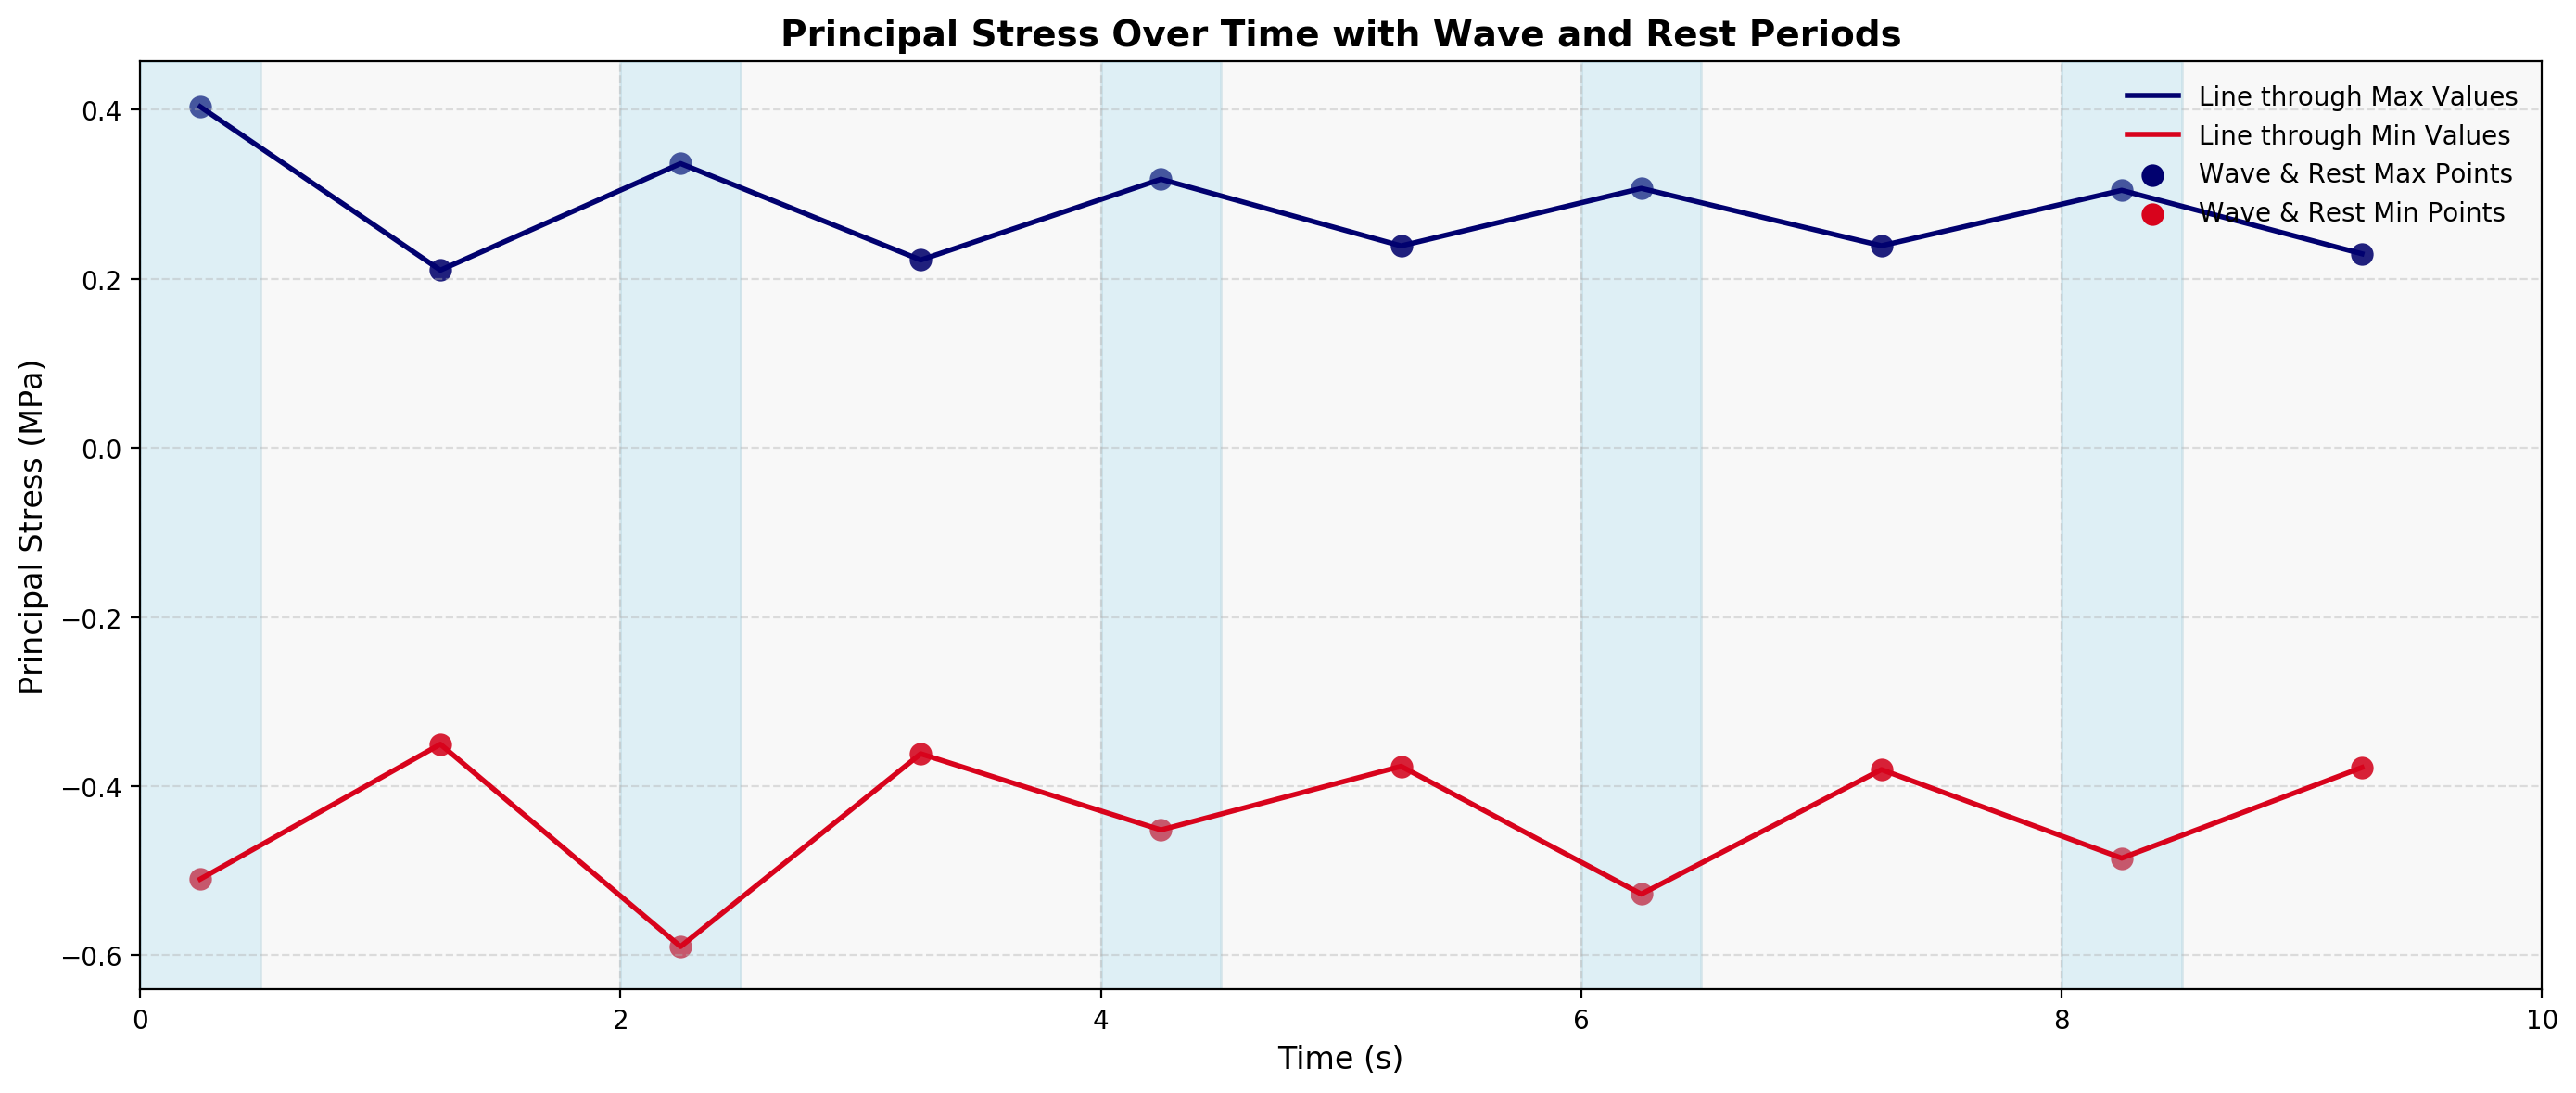

In [28]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# File path
# -------------------------------
csv_path = 'principal_stress_per_block_H05-2300_30.csv'

# -------------------------------
# Load data
# -------------------------------
df = pd.read_csv(csv_path)

# Time vector
time = df['Time']

# Find all _max and _min columns
max_cols = [col for col in df.columns if col.endswith('_max')]
min_cols = [col for col in df.columns if col.endswith('_min')]

# Compute row-wise min and max across blocks
max_across_blocks = df[max_cols].max(axis=1)
min_across_blocks = df[min_cols].min(axis=1)

# -------------------------------
# Define wave windows
# -------------------------------
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]

# Compute subsequent wave starts
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

# Create list of (start, end) tuples for waves
wave_periods = [(start, start + wave_duration) for start in wave_starts]

# Create list of (start, end) tuples for rest periods
rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    if rest_start < time.max():
        rest_end = min(rest_end, time.max())
        rest_periods.append((rest_start, rest_end))

# -------------------------------
# Analyze waves and rest periods
# -------------------------------
points_time = []
points_max = []
points_min = []

for i, (wave_start, wave_end) in enumerate(wave_periods):
    # Wave period mask
    mask_wave = (time >= wave_start) & (time <= wave_end)

    # Extract wave data for all blocks
    wave_df_max = df.loc[mask_wave, max_cols]
    wave_df_min = df.loc[mask_wave, min_cols]

    # True max of max and min of min across all blocks and time
    max_max_wave = wave_df_max.values.max() / 1e6
    min_min_wave = wave_df_min.values.min() / 1e6

    wave_center = (wave_start + wave_end) / 2

    # Save wave point
    points_time.append(wave_center)
    points_max.append(max_max_wave)
    points_min.append(min_min_wave)

    # Corresponding rest period
    if i < len(rest_periods):
        rest_start, rest_end = rest_periods[i]
        mask_rest = (time > rest_start) & (time <= rest_end)

        avg_max_rest = max_across_blocks[mask_rest].mean() / 1e6
        avg_min_rest = min_across_blocks[mask_rest].mean() / 1e6

        rest_center = (rest_start + rest_end) / 2

        # Save rest point
        points_time.append(rest_center)
        points_max.append(avg_max_rest)
        points_min.append(avg_min_rest)

# Convert to numpy arrays
points_time = np.array(points_time)
points_max = np.array(points_max)
points_min = np.array(points_min)

# Sort chronologically
sort_idx = np.argsort(points_time)
points_time = points_time[sort_idx]
points_max = points_max[sort_idx]
points_min = points_min[sort_idx]

# -------------------------------
# Plotting
# -------------------------------
fig, ax = plt.subplots(
    figsize=(14, 6),
    dpi=200,
    facecolor='white'
)

ax.set_facecolor('white')

# Plot stress curves
# ax.plot(
#     time,
#     min_across_blocks / 1e6,
#     color='#d8031c',
#     linewidth=1.5,
#     label='Min Principal Stress (min across blocks)'
# )

# ax.plot(
#     time,
#     max_across_blocks / 1e6,
#     color='#01016f',
#     linewidth=1.5,
#     label='Max Principal Stress (max across blocks)'
# )

# Shade wave periods
for start, end in wave_periods:
    ax.axvspan(start, end, color='lightblue', alpha=0.4)

# Shade rest periods
for start, end in rest_periods:
    ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# Plot points
ax.scatter(
    points_time,
    points_max,
    color='#01016f',
    marker='o',
    s=60,
    label='Wave & Rest Max Points'
)

ax.scatter(
    points_time,
    points_min,
    color='#d8031c',
    marker='o',
    s=60,
    label='Wave & Rest Min Points'
)

# Plot single continuous lines through all points
ax.plot(
    points_time,
    points_max,
    color='#01016f',
    linestyle='-',
    linewidth=2,
    label='Line through Max Values'
)

ax.plot(
    points_time,
    points_min,
    color='#d8031c',
    linestyle='-',
    linewidth=2,
    label='Line through Min Values'
)

# Labels and style
ax.set_title("Principal Stress Over Time with Wave and Rest Periods", fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Principal Stress (MPa)", fontsize=12)
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


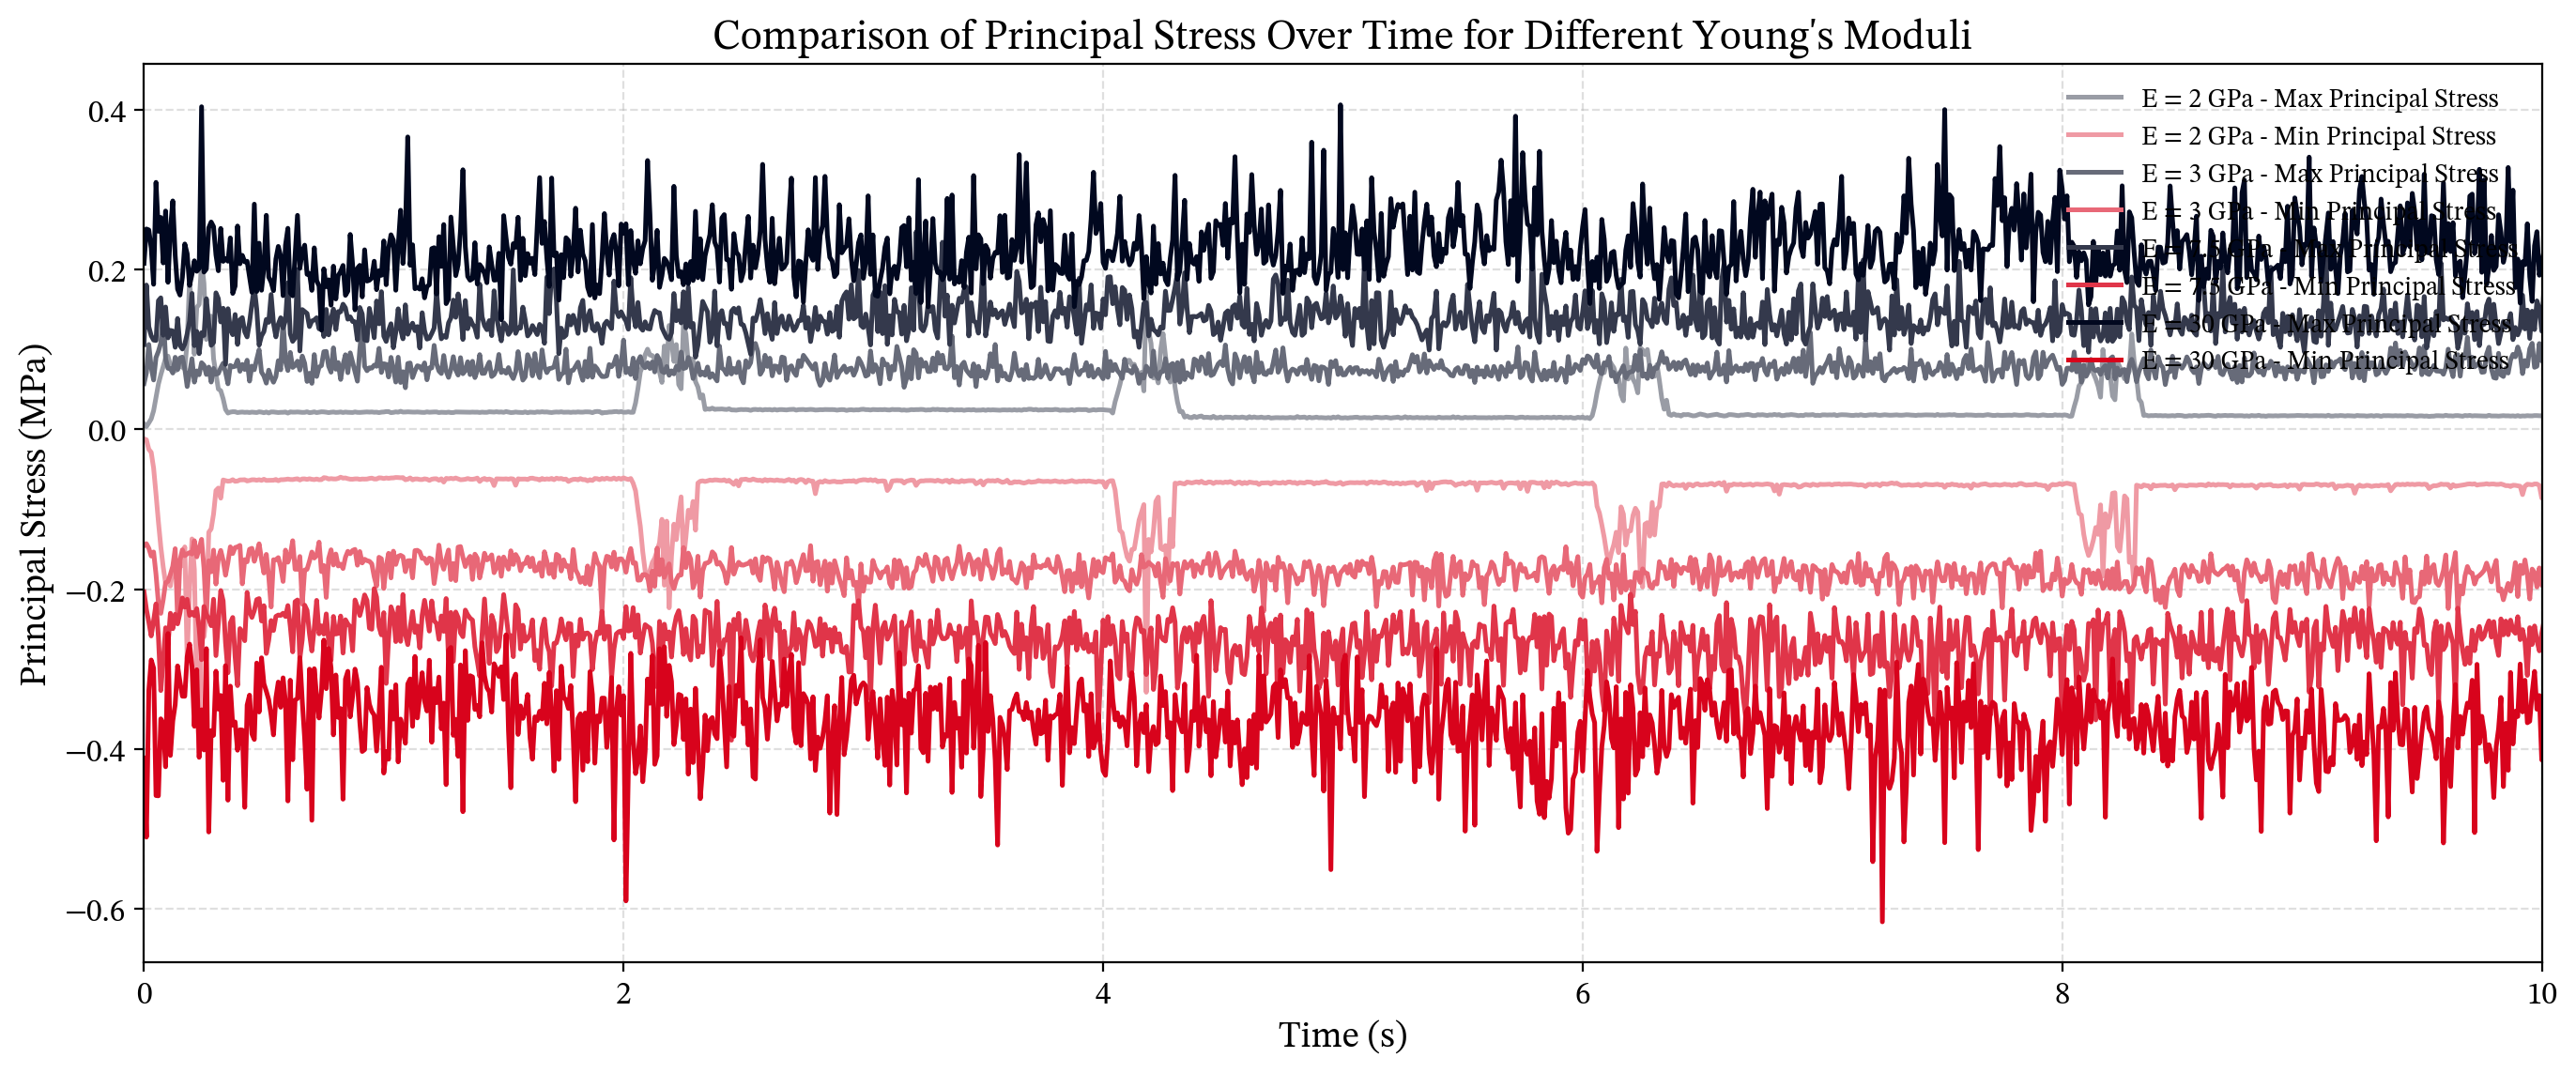

In [29]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Force white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 16

# --------------------------------------------
# File paths and color definitions
# --------------------------------------------
files_and_labels = [
    ('principal_stress_per_block_H05-2300_2.csv', 'E = 2 GPa'),
    ('principal_stress_per_block_H05-2300_3.csv', 'E = 3 GPa'),
    ('principal_stress_per_block_H05-2300_7.csv', 'E = 7.5 GPa'),
    ('principal_stress_per_block_H05-2300_30.csv', 'E = 30 GPa')
]

# Dark blue and red for 30 GPa
color_max_base = np.array([1, 8, 31]) / 255.0   # dark navy
color_min_base = np.array([216, 3, 28]) / 255.0 # dark red

# Compute lighter colors for other datasets
n_files = len(files_and_labels)
color_factors = np.linspace(0.4, 1.0, n_files)

colors_max = [(color_max_base * f + (1-f)) for f in color_factors]
colors_min = [(color_min_base * f + (1-f)) for f in color_factors]

# --------------------------------------------
# Plotting
# --------------------------------------------
fig, ax = plt.subplots(
    figsize=(14, 6),
    dpi=200,
    facecolor='white'
)
ax.set_facecolor('white')

for idx, (csv_path, label) in enumerate(files_and_labels):
    df = pd.read_csv(csv_path)

    time = df['Time']

    # Find all _max and _min columns
    max_cols = [col for col in df.columns if col.endswith('_max')]
    min_cols = [col for col in df.columns if col.endswith('_min')]

    # Compute row-wise min and max across blocks
    max_across_blocks = df[max_cols].max(axis=1)
    min_across_blocks = df[min_cols].min(axis=1)

    # Plot max curve
    ax.plot(
        time,
        max_across_blocks / 1e6,
        color=colors_max[idx],
        linewidth=1.8,
        label=f"{label} - Max Principal Stress"
    )

    # Plot min curve
    ax.plot(
        time,
        min_across_blocks / 1e6,
        color=colors_min[idx],
        linewidth=1.8,
        label=f"{label} - Min Principal Stress"
    )

# --------------------------------------------
# Labels and style
# --------------------------------------------
ax.set_title("Comparison of Principal Stress Over Time for Different Young's Moduli", fontsize=16, fontweight='bold')
ax.set_xlabel("Time (s)", fontsize=14)
ax.set_ylabel("Principal Stress (MPa)", fontsize=14)
ax.legend(fontsize=10, loc='upper right', frameon=False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(labelsize=12)
ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()


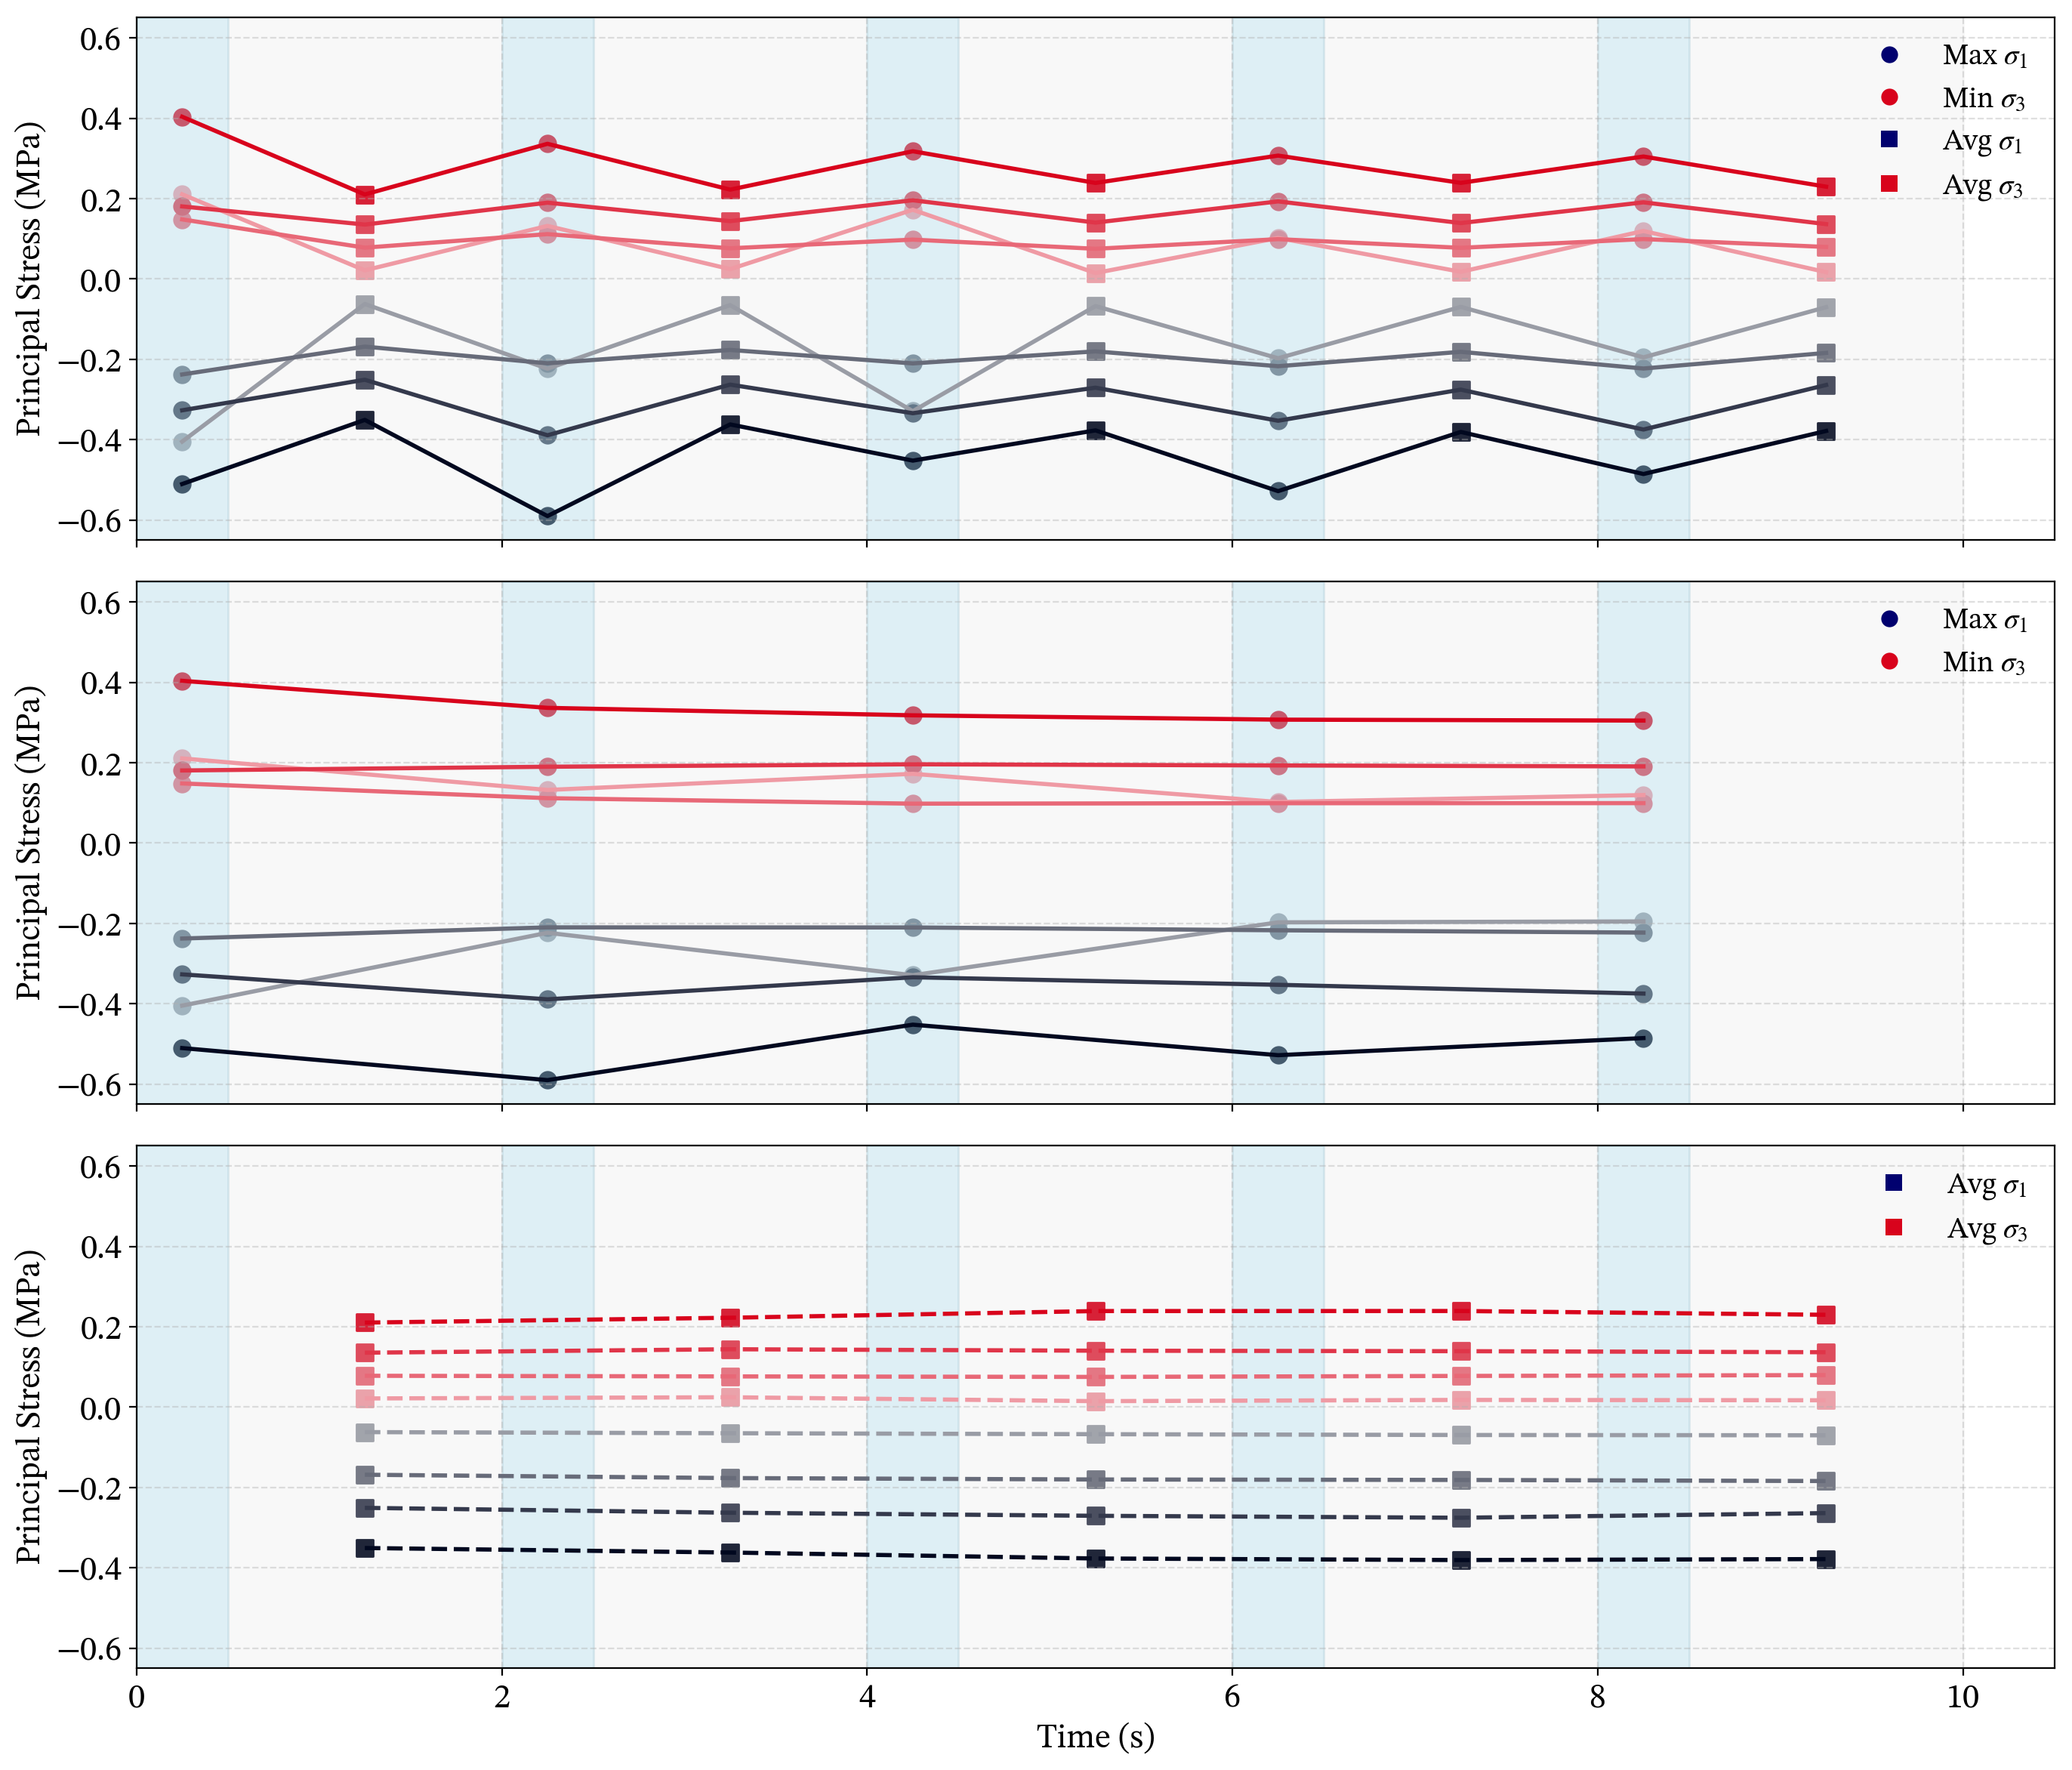

In [61]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# ---------------------------------------------
# Matplotlib styling
# ---------------------------------------------
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 16

# ---------------------------------------------
# Files and labels
# ---------------------------------------------
files_and_labels = [
    ('principal_stress_per_block_H05-2300_2.csv', 'E = 2 GPa'),
    ('principal_stress_per_block_H05-2300_3.csv', 'E = 3 GPa'),
    ('principal_stress_per_block_H05-2300_7.csv', 'E = 7.5 GPa'),
    ('principal_stress_per_block_H05-2300_30.csv', 'E = 30 GPa'),
]

# Define base dark colors
color_max_base = np.array([216, 3, 28]) / 255.0  # dark red  
color_min_base = np.array([1, 8, 31]) / 255.0    # dark navy

n_files = len(files_and_labels)
color_factors = np.linspace(0.4, 1.0, n_files)

colors_max = [(color_max_base * f + (1 - f)) for f in color_factors]
colors_min = [(color_min_base * f + (1 - f)) for f in color_factors]

# ---------------------------------------------
# Wave and rest periods
# ---------------------------------------------
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

wave_periods = [(start, start + wave_duration) for start in wave_starts]

rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    rest_periods.append((rest_start, rest_end))

# ---------------------------------------------
# Create figure and subplots
# ---------------------------------------------
fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 12),
    dpi=200,
    sharex=True
)

# Shade wave/rest in all subplots
for ax in axs:
    for start, end in wave_periods:
        ax.axvspan(start, end, color='lightblue', alpha=0.4)
    for start, end in rest_periods:
        ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# ---------------------------------------------
# Process and plot each file
# ---------------------------------------------
for idx, (csv_path, label) in enumerate(files_and_labels):

    df = pd.read_csv(csv_path)
    time = df['Time']
    max_cols = [col for col in df.columns if col.endswith('_max')]
    min_cols = [col for col in df.columns if col.endswith('_min')]

    max_across_blocks = df[max_cols].max(axis=1)
    min_across_blocks = df[min_cols].min(axis=1)

    wave_centers = []
    wave_max_vals = []
    wave_min_vals = []

    rest_centers = []
    rest_avg_max_vals = []
    rest_avg_min_vals = []

    for i, (wave_start, wave_end) in enumerate(wave_periods):
        mask_wave = (time >= wave_start) & (time <= wave_end)

        wave_df_max = df.loc[mask_wave, max_cols]
        wave_df_min = df.loc[mask_wave, min_cols]

        max_max_wave = wave_df_max.values.max() / 1e6
        min_min_wave = wave_df_min.values.min() / 1e6

        wave_center = (wave_start + wave_end) / 2
        wave_centers.append(wave_center)
        wave_max_vals.append(max_max_wave)
        wave_min_vals.append(min_min_wave)

        if i < len(rest_periods):
            rest_start, rest_end = rest_periods[i]
            mask_rest = (time > rest_start) & (time <= rest_end)

            avg_max_rest = max_across_blocks[mask_rest].mean() / 1e6
            avg_min_rest = min_across_blocks[mask_rest].mean() / 1e6

            rest_center = (rest_start + rest_end) / 2
            rest_centers.append(rest_center)
            rest_avg_max_vals.append(avg_max_rest)
            rest_avg_min_vals.append(avg_min_rest)

    # Convert to numpy and sort
    points_time = []
    points_max = []
    points_min = []

    for t, val_max, val_min in zip(wave_centers, wave_max_vals, wave_min_vals):
        points_time.append(t)
        points_max.append(val_max)
        points_min.append(val_min)
    for t, val_max, val_min in zip(rest_centers, rest_avg_max_vals, rest_avg_min_vals):
        points_time.append(t)
        points_max.append(val_max)
        points_min.append(val_min)

    points_time = np.array(points_time)
    points_max = np.array(points_max)
    points_min = np.array(points_min)

    sort_idx = np.argsort(points_time)
    points_time = points_time[sort_idx]
    points_max = points_max[sort_idx]
    points_min = points_min[sort_idx]

    # --- Main plot ---
    axs[0].scatter(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        marker='o',
        s=60,
    )
    axs[0].scatter(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        marker='o',
        s=60,
    )
    axs[0].scatter(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        marker='s',
        s=60,
    )
    axs[0].scatter(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        marker='s',
        s=60,
    )

    axs[0].plot(
        points_time,
        points_max,
        color=colors_max[idx],
        linestyle='-',
        linewidth=2
    )
    axs[0].plot(
        points_time,
        points_min,
        color=colors_min[idx],
        linestyle='-',
        linewidth=2
    )

    # --- Subplot 2: only wave min/max ---
    axs[1].scatter(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        marker='o',
        s=60
    )
    axs[1].scatter(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        marker='o',
        s=60
    )
    axs[1].plot(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        linestyle='-',
        linewidth=2,
    )
    axs[1].plot(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        linestyle='-',
        linewidth=2,
    )

    # --- Subplot 3: only rest averages ---
    axs[2].scatter(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        marker='s',
        s=60
    )
    axs[2].scatter(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        marker='s',
        s=60
    )
    axs[2].plot(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        linestyle='--',
        linewidth=2,
    )
    axs[2].plot(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        linestyle='--',
        linewidth=2,
    )

# ---------------------------------------------
# Titles and styling
# ---------------------------------------------
for ax in axs:
    ax.set_xlim(0, 10.5)
    ax.set_ylim(-0.65, 0.65)
    ax.set_ylabel("Principal Stress (MPa)")
    ax.grid(True, linestyle='--', alpha=0.4)

axs[-1].set_xlabel("Time (s)")

# --- Legend for subplot 1 ---
legend_elements_main = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#01016f', markersize=8,
           label=r'Max $\sigma_1$'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#d8031c', markersize=8,
           label=r'Min $\sigma_3$'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#01016f', markersize=8,
           label=r'Avg $\sigma_1$'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#d8031c', markersize=8,
           label=r'Avg $\sigma_3$'),
]
axs[0].legend(handles=legend_elements_main, fontsize=14, frameon=False, loc='upper right')

# --- Legend for subplot 2 ---
legend_elements_wave = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#01016f', markersize=8,
           label=r'Max $\sigma_1$'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#d8031c', markersize=8,
           label=r'Min $\sigma_3$'),
]
axs[1].legend(handles=legend_elements_wave, fontsize=14, frameon=False, loc='upper right')

# --- Legend for subplot 3 ---
legend_elements_rest = [
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#01016f', markersize=8,
           label=r'Avg $\sigma_1$'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#d8031c', markersize=8,
           label=r'Avg $\sigma_3$'),
]
axs[2].legend(handles=legend_elements_rest, fontsize=14, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()


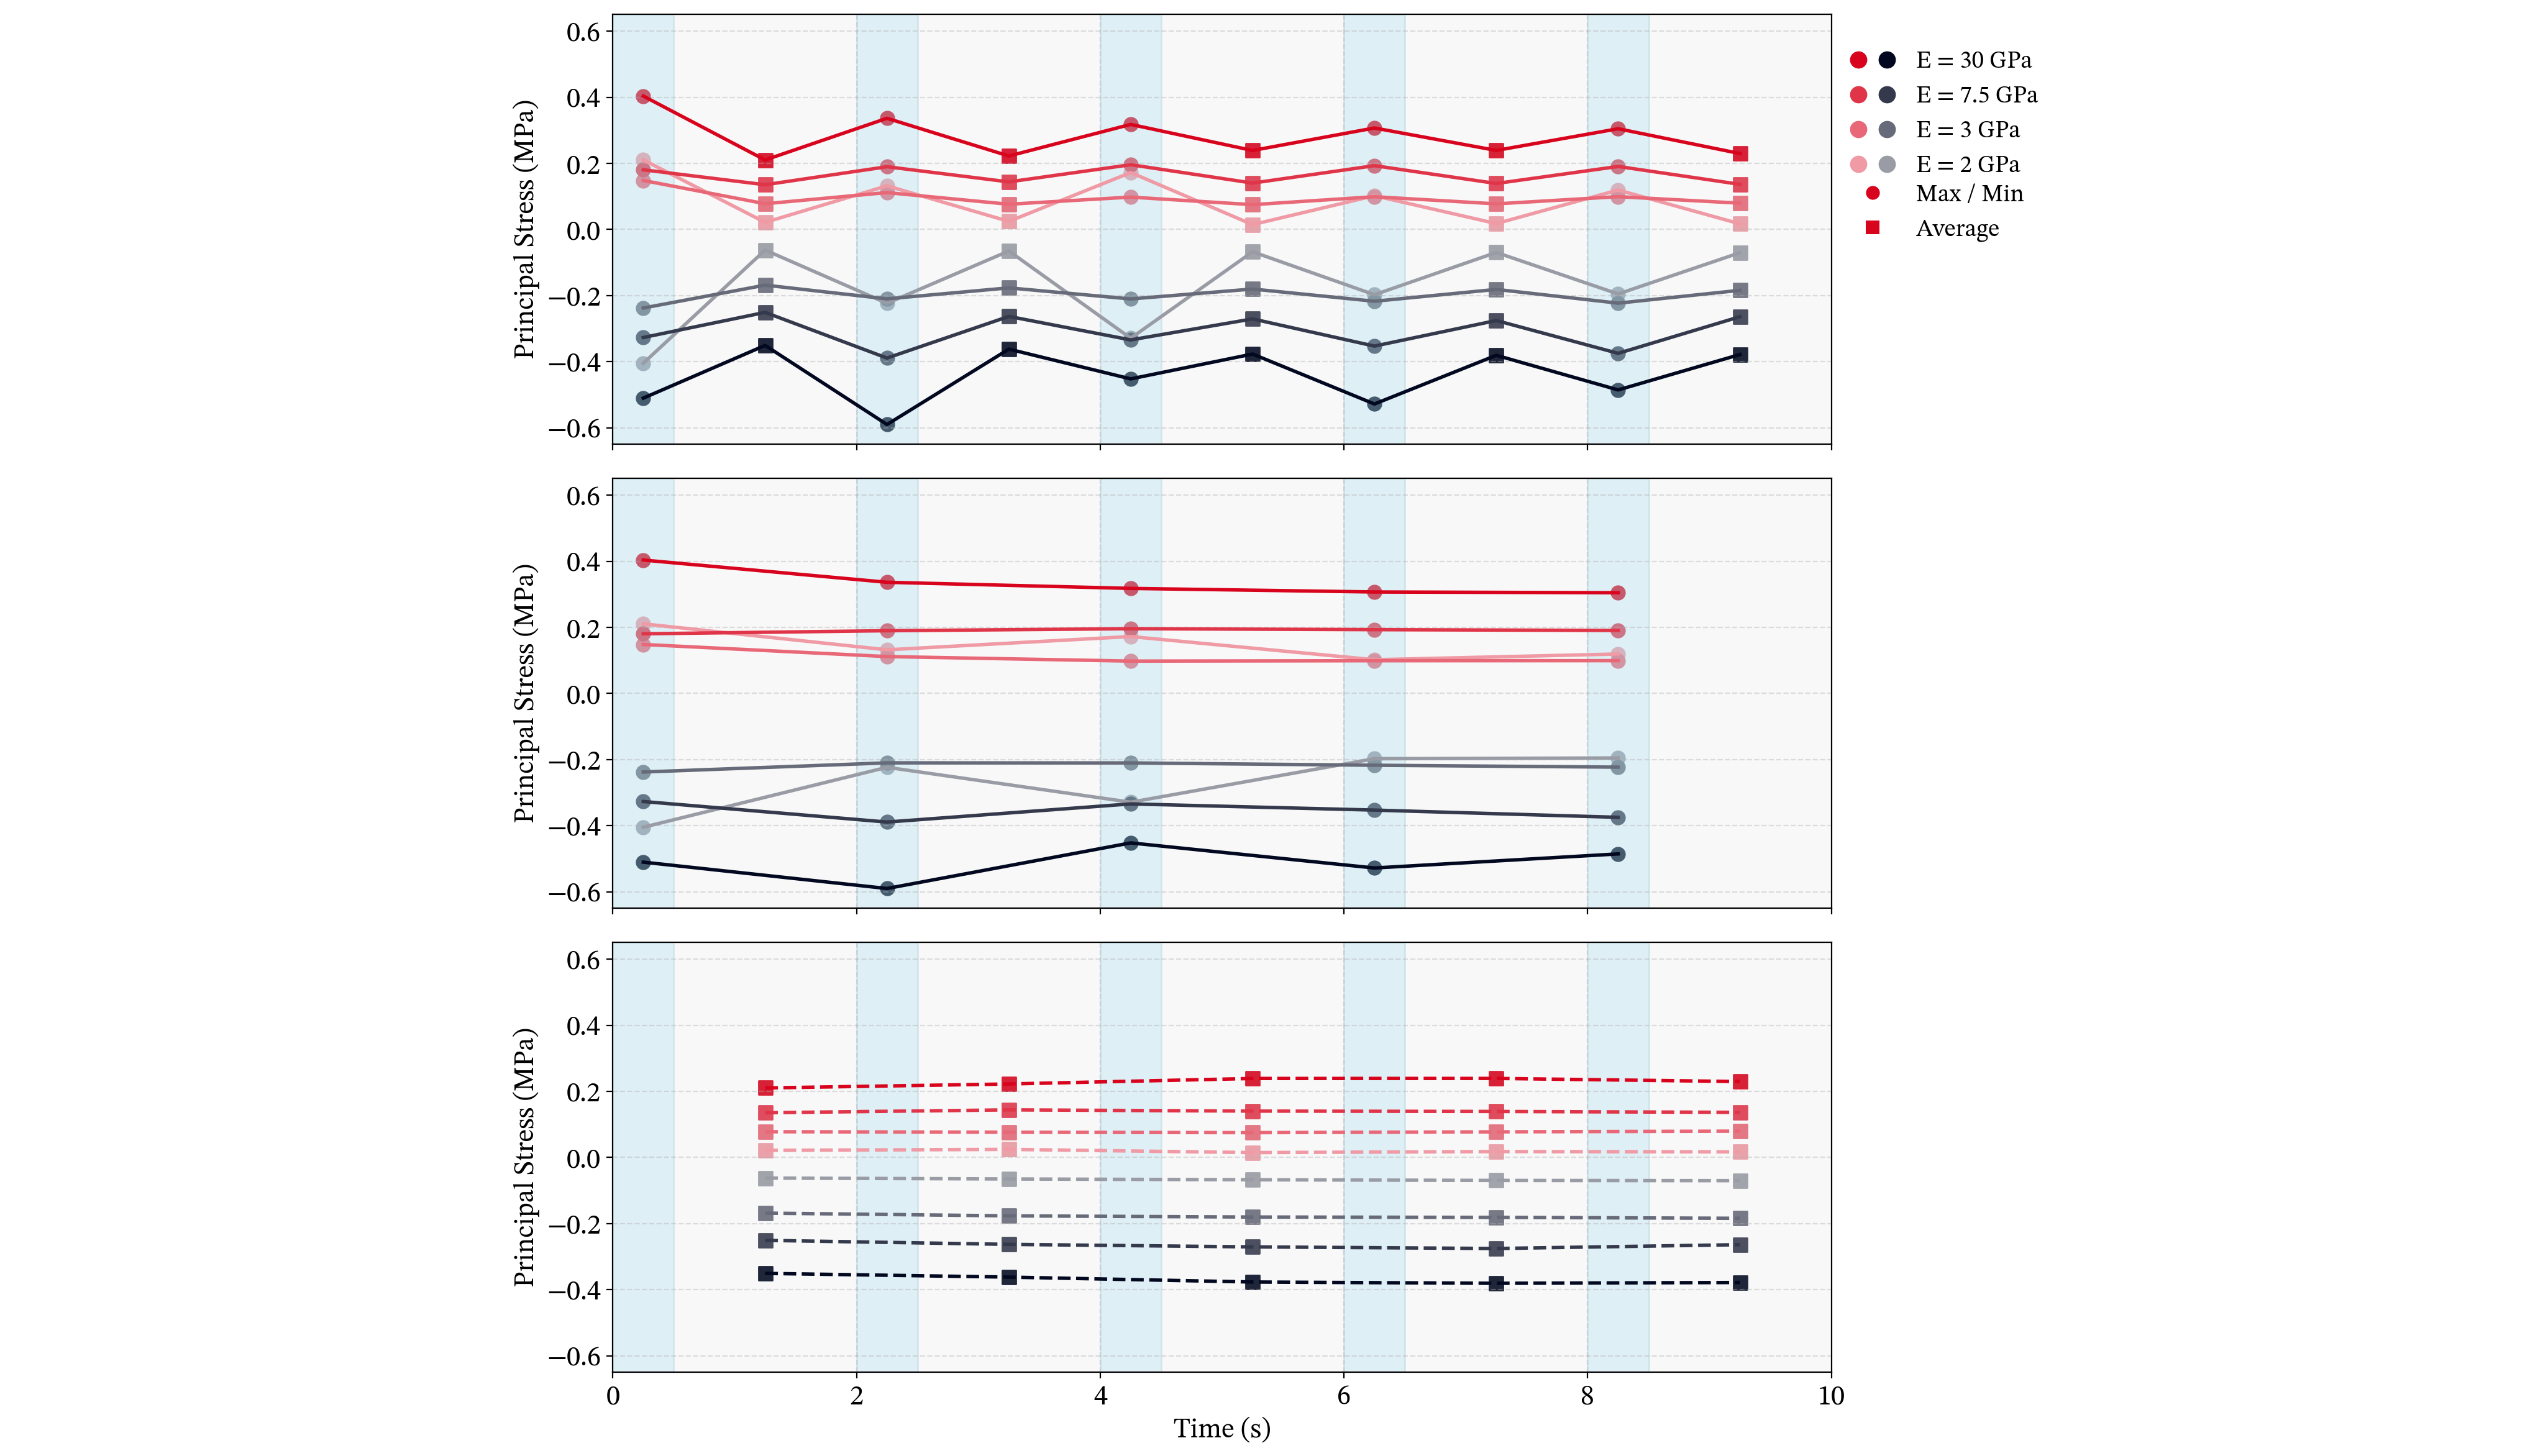

In [43]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ---------------------------------------------
# Matplotlib styling
# ---------------------------------------------
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 16

# ---------------------------------------------
# Files and labels
# ---------------------------------------------
files_and_labels = [
    ('principal_stress_per_block_H05-2300_2.csv', 'E = 2 GPa'),
    ('principal_stress_per_block_H05-2300_3.csv', 'E = 3 GPa'),
    ('principal_stress_per_block_H05-2300_7.csv', 'E = 7.5 GPa'),
    ('principal_stress_per_block_H05-2300_30.csv', 'E = 30 GPa'),
]

# Define base dark colors
color_max_base = np.array([216, 3, 28]) / 255.0  # dark red
color_min_base = np.array([1, 8, 31]) / 255.0    # dark navy

n_files = len(files_and_labels)
color_factors = np.linspace(0.4, 1.0, n_files)

colors_max = [(color_max_base * f + (1 - f)) for f in color_factors]
colors_min = [(color_min_base * f + (1 - f)) for f in color_factors]

# ---------------------------------------------
# Wave and rest periods
# ---------------------------------------------
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

wave_periods = [(start, start + wave_duration) for start in wave_starts]

rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    rest_periods.append((rest_start, rest_end))

# ---------------------------------------------
# Create figure and subplots
# ---------------------------------------------
fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 12),
    dpi=200,
    sharex=True
)

# Shade wave/rest in all subplots
for ax in axs:
    for start, end in wave_periods:
        ax.axvspan(start, end, color='lightblue', alpha=0.4)
    for start, end in rest_periods:
        ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# ---------------------------------------------
# Process and plot each file
# ---------------------------------------------
legend_handles = []
legend_labels = []

for idx, (csv_path, label) in enumerate(files_and_labels):

    df = pd.read_csv(csv_path)
    time = df['Time']
    max_cols = [col for col in df.columns if col.endswith('_max')]
    min_cols = [col for col in df.columns if col.endswith('_min')]

    max_across_blocks = df[max_cols].max(axis=1)
    min_across_blocks = df[min_cols].min(axis=1)

    wave_centers = []
    wave_max_vals = []
    wave_min_vals = []

    rest_centers = []
    rest_avg_max_vals = []
    rest_avg_min_vals = []

    for i, (wave_start, wave_end) in enumerate(wave_periods):
        mask_wave = (time >= wave_start) & (time <= wave_end)

        wave_df_max = df.loc[mask_wave, max_cols]
        wave_df_min = df.loc[mask_wave, min_cols]

        max_max_wave = wave_df_max.values.max() / 1e6
        min_min_wave = wave_df_min.values.min() / 1e6

        wave_center = (wave_start + wave_end) / 2
        wave_centers.append(wave_center)
        wave_max_vals.append(max_max_wave)
        wave_min_vals.append(min_min_wave)

        if i < len(rest_periods):
            rest_start, rest_end = rest_periods[i]
            mask_rest = (time > rest_start) & (time <= rest_end)

            avg_max_rest = max_across_blocks[mask_rest].mean() / 1e6
            avg_min_rest = min_across_blocks[mask_rest].mean() / 1e6

            rest_center = (rest_start + rest_end) / 2
            rest_centers.append(rest_center)
            rest_avg_max_vals.append(avg_max_rest)
            rest_avg_min_vals.append(avg_min_rest)

    # Convert to numpy and sort
    points_time = []
    points_max = []
    points_min = []

    for t, val_max, val_min in zip(wave_centers, wave_max_vals, wave_min_vals):
        points_time.append(t)
        points_max.append(val_max)
        points_min.append(val_min)
    for t, val_max, val_min in zip(rest_centers, rest_avg_max_vals, rest_avg_min_vals):
        points_time.append(t)
        points_max.append(val_max)
        points_min.append(val_min)

    points_time = np.array(points_time)
    points_max = np.array(points_max)
    points_min = np.array(points_min)

    sort_idx = np.argsort(points_time)
    points_time = points_time[sort_idx]
    points_max = points_max[sort_idx]
    points_min = points_min[sort_idx]

    # --- Main plot ---
    axs[0].scatter(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        marker='o',
        s=60,
    )
    axs[0].scatter(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        marker='o',
        s=60,
    )
    axs[0].scatter(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        marker='s',
        s=60,
    )
    axs[0].scatter(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        marker='s',
        s=60,
    )

    axs[0].plot(
        points_time,
        points_max,
        color=colors_max[idx],
        linestyle='-',
        linewidth=2
    )
    axs[0].plot(
        points_time,
        points_min,
        color=colors_min[idx],
        linestyle='-',
        linewidth=2
    )

    # Subplot 2
    axs[1].scatter(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        marker='o',
        s=60
    )
    axs[1].scatter(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        marker='o',
        s=60
    )
    axs[1].plot(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        linestyle='-',
        linewidth=2,
    )
    axs[1].plot(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        linestyle='-',
        linewidth=2,
    )

    # Subplot 3
    axs[2].scatter(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        marker='s',
        s=60
    )
    axs[2].scatter(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        marker='s',
        s=60
    )
    axs[2].plot(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        linestyle='--',
        linewidth=2,
    )
    axs[2].plot(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        linestyle='--',
        linewidth=2,
    )

    # Create a tuple of two markers as legend handle
    dot_max = Line2D([0], [0], marker='o', color='none', markerfacecolor=colors_max[idx], markersize=10)
    dot_min = Line2D([0], [0], marker='o', color='none', markerfacecolor=colors_min[idx], markersize=10)

    legend_handles.append((dot_max, dot_min))
    legend_labels.append(label)

# Adjust subplot layout for equal margins
plt.subplots_adjust(left=-0.2, right=0.9)

for ax in axs:
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.65, 0.65)
    ax.set_ylabel("Principal Stress (MPa)")
    ax.grid(True, linestyle='--', alpha=0.4)

axs[-1].set_xlabel("Time (s)")

# Sort legend handles and labels by Young’s modulus (descending)
sorted_indices = np.argsort(
    [-float(lbl.split('=')[1].replace('GPa','').strip()) for lbl in legend_labels]
)
legend_handles_sorted = [legend_handles[i] for i in sorted_indices]
legend_labels_sorted = [legend_labels[i] for i in sorted_indices]

# --- Legend for each dataset ---
fig.legend(
    legend_handles_sorted,
    legend_labels_sorted,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='center left',
    bbox_to_anchor=(1.05, 0.9),
    fontsize=14,
    frameon=False
)

fig.legend(
    [], [],  # no handles, no labels
    loc='center right',
    bbox_to_anchor=(-0.25, 0.5),
    frameon=False
)

# --- Legend for symbols (below) ---
symbol_legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#d8031c', markersize=8, label='Max / Min'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#d8031c', markersize=8, label='Average'),
]

fig.legend(
    handles=symbol_legend_elements,
    loc='lower left',
    bbox_to_anchor=(1.05, 0.80),
    fontsize=14,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.savefig('principal_stress_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


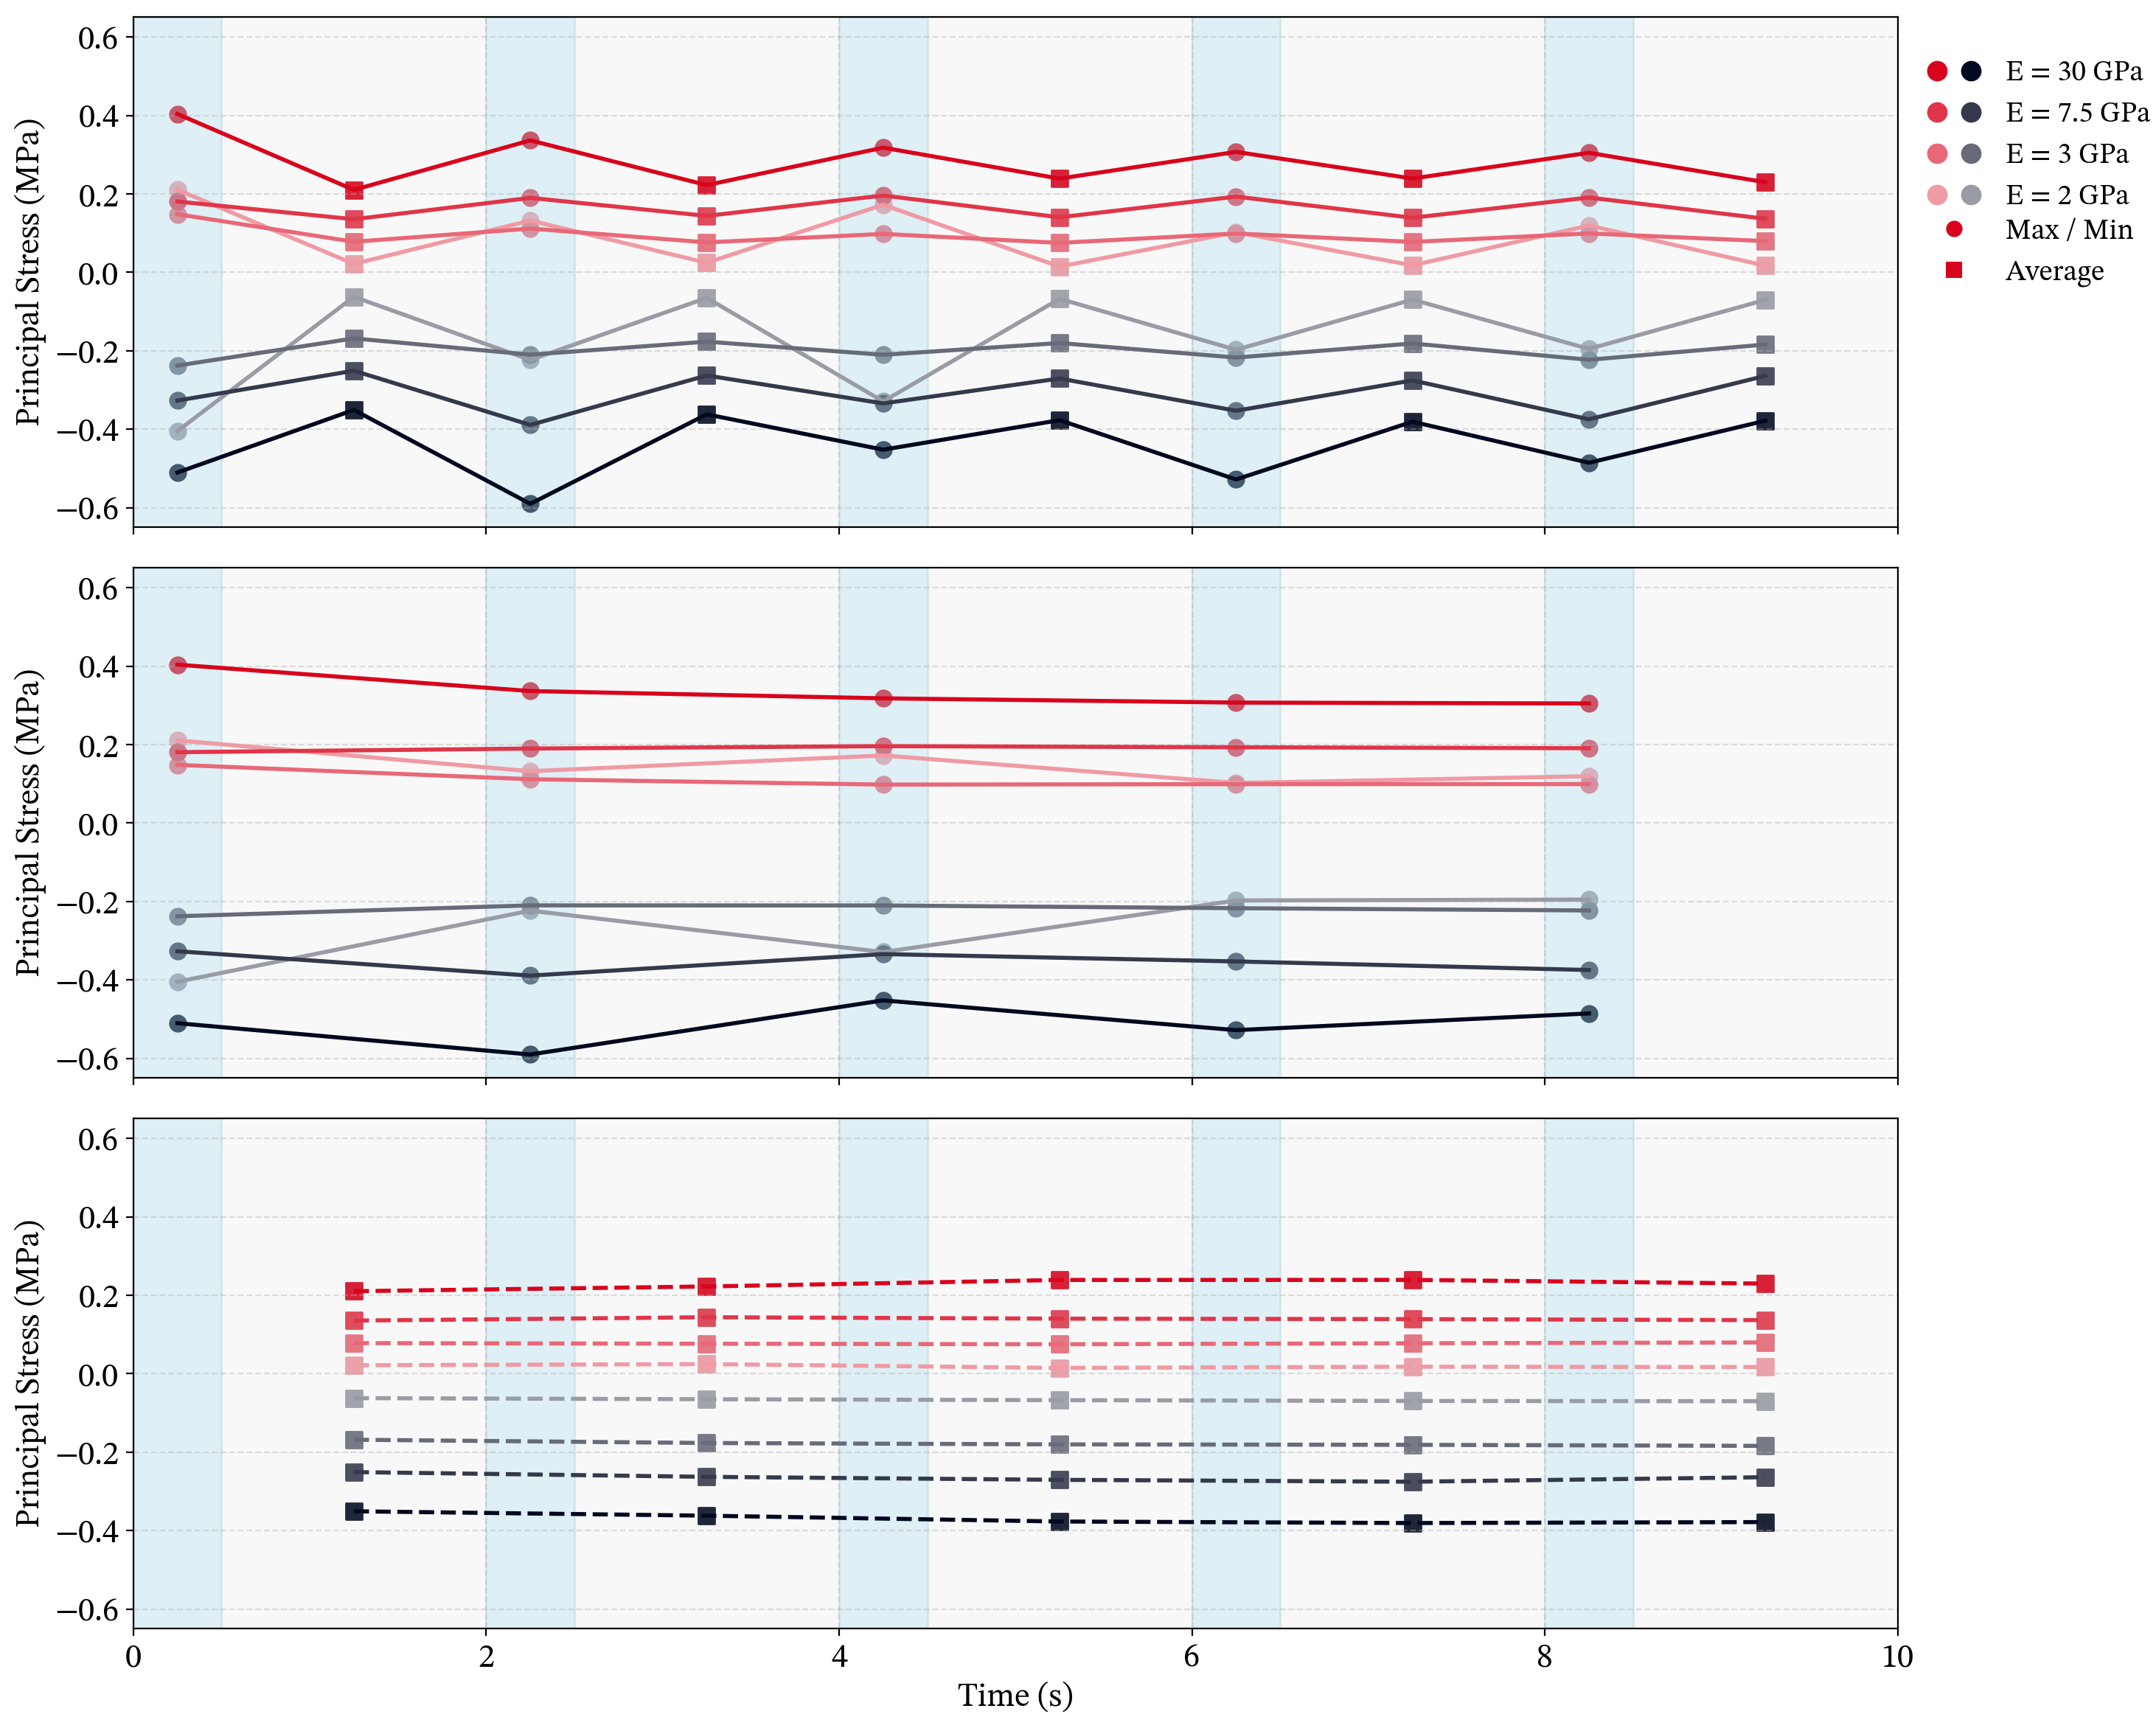

In [69]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ---------------------------------------------
# Matplotlib styling
# ---------------------------------------------
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 16

# ---------------------------------------------
# Files and labels
# ---------------------------------------------
files_and_labels = [
    ('principal_stress_per_block_H05-2300_2.csv', 'E = 2 GPa'),
    ('principal_stress_per_block_H05-2300_3.csv', 'E = 3 GPa'),
    ('principal_stress_per_block_H05-2300_7.csv', 'E = 7.5 GPa'),
    ('principal_stress_per_block_H05-2300_30.csv', 'E = 30 GPa'),
]

# Define base dark colors
color_max_base = np.array([216, 3, 28]) / 255.0  # dark red
color_min_base = np.array([1, 8, 31]) / 255.0    # dark navy

n_files = len(files_and_labels)
color_factors = np.linspace(0.4, 1.0, n_files)

colors_max = [(color_max_base * f + (1 - f)) for f in color_factors]
colors_min = [(color_min_base * f + (1 - f)) for f in color_factors]

# ---------------------------------------------
# Wave and rest periods
# ---------------------------------------------
wave_duration = 0.5
rest_duration = 1.5

wave_starts = [0.0]
for i in range(1, 5):
    prev_start = wave_starts[-1]
    next_start = prev_start + wave_duration + rest_duration
    wave_starts.append(next_start)

wave_periods = [(start, start + wave_duration) for start in wave_starts]

rest_periods = []
for start, end in wave_periods:
    rest_start = end
    rest_end = rest_start + rest_duration
    rest_periods.append((rest_start, rest_end))

# ---------------------------------------------
# Create figure and subplots
# ---------------------------------------------
fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 12),
    dpi=200,
    sharex=True
)

# Shade wave/rest in all subplots
for ax in axs:
    for start, end in wave_periods:
        ax.axvspan(start, end, color='lightblue', alpha=0.4)
    for start, end in rest_periods:
        ax.axvspan(start, end, color='lightgrey', alpha=0.15)

# ---------------------------------------------
# Process and plot each file
# ---------------------------------------------
legend_handles = []
legend_labels = []

for idx, (csv_path, label) in enumerate(files_and_labels):

    df = pd.read_csv(csv_path)
    time = df['Time']
    max_cols = [col for col in df.columns if col.endswith('_max')]
    min_cols = [col for col in df.columns if col.endswith('_min')]

    max_across_blocks = df[max_cols].max(axis=1)
    min_across_blocks = df[min_cols].min(axis=1)

    wave_centers = []
    wave_max_vals = []
    wave_min_vals = []

    rest_centers = []
    rest_avg_max_vals = []
    rest_avg_min_vals = []

    for i, (wave_start, wave_end) in enumerate(wave_periods):
        mask_wave = (time >= wave_start) & (time <= wave_end)

        wave_df_max = df.loc[mask_wave, max_cols]
        wave_df_min = df.loc[mask_wave, min_cols]

        max_max_wave = wave_df_max.values.max() / 1e6
        min_min_wave = wave_df_min.values.min() / 1e6

        wave_center = (wave_start + wave_end) / 2
        wave_centers.append(wave_center)
        wave_max_vals.append(max_max_wave)
        wave_min_vals.append(min_min_wave)

        if i < len(rest_periods):
            rest_start, rest_end = rest_periods[i]
            mask_rest = (time > rest_start) & (time <= rest_end)

            avg_max_rest = max_across_blocks[mask_rest].mean() / 1e6
            avg_min_rest = min_across_blocks[mask_rest].mean() / 1e6

            rest_center = (rest_start + rest_end) / 2
            rest_centers.append(rest_center)
            rest_avg_max_vals.append(avg_max_rest)
            rest_avg_min_vals.append(avg_min_rest)

    # Convert to numpy and sort
    points_time = []
    points_max = []
    points_min = []

    for t, val_max, val_min in zip(wave_centers, wave_max_vals, wave_min_vals):
        points_time.append(t)
        points_max.append(val_max)
        points_min.append(val_min)
    for t, val_max, val_min in zip(rest_centers, rest_avg_max_vals, rest_avg_min_vals):
        points_time.append(t)
        points_max.append(val_max)
        points_min.append(val_min)

    points_time = np.array(points_time)
    points_max = np.array(points_max)
    points_min = np.array(points_min)

    sort_idx = np.argsort(points_time)
    points_time = points_time[sort_idx]
    points_max = points_max[sort_idx]
    points_min = points_min[sort_idx]

    # --- Main plot ---
    axs[0].scatter(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        marker='o',
        s=60,
    )
    axs[0].scatter(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        marker='o',
        s=60,
    )
    axs[0].scatter(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        marker='s',
        s=60,
    )
    axs[0].scatter(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        marker='s',
        s=60,
    )

    axs[0].plot(
        points_time,
        points_max,
        color=colors_max[idx],
        linestyle='-',
        linewidth=2
    )
    axs[0].plot(
        points_time,
        points_min,
        color=colors_min[idx],
        linestyle='-',
        linewidth=2
    )

    # Subplot 2
    axs[1].scatter(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        marker='o',
        s=60
    )
    axs[1].scatter(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        marker='o',
        s=60
    )
    axs[1].plot(
        wave_centers,
        wave_max_vals,
        color=colors_max[idx],
        linestyle='-',
        linewidth=2,
    )
    axs[1].plot(
        wave_centers,
        wave_min_vals,
        color=colors_min[idx],
        linestyle='-',
        linewidth=2,
    )

    # Subplot 3
    axs[2].scatter(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        marker='s',
        s=60
    )
    axs[2].scatter(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        marker='s',
        s=60
    )
    axs[2].plot(
        rest_centers,
        rest_avg_max_vals,
        color=colors_max[idx],
        linestyle='--',
        linewidth=2,
    )
    axs[2].plot(
        rest_centers,
        rest_avg_min_vals,
        color=colors_min[idx],
        linestyle='--',
        linewidth=2,
    )

    # Create a tuple of two markers as legend handle
    dot_max = Line2D([0], [0], marker='o', color='none', markerfacecolor=colors_max[idx], markersize=10)
    dot_min = Line2D([0], [0], marker='o', color='none', markerfacecolor=colors_min[idx], markersize=10)

    legend_handles.append((dot_max, dot_min))
    legend_labels.append(label)



for ax in axs:
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.65, 0.65)
    ax.set_ylabel("Principal Stress (MPa)")
    ax.grid(True, linestyle='--', alpha=0.4)

axs[-1].set_xlabel("Time (s)")

# Sort legend handles and labels by Young’s modulus (descending)
sorted_indices = np.argsort(
    [-float(lbl.split('=')[1].replace('GPa','').strip()) for lbl in legend_labels]
)
legend_handles_sorted = [legend_handles[i] for i in sorted_indices]
legend_labels_sorted = [legend_labels[i] for i in sorted_indices]

# --- Legend for each dataset ---
fig.legend(
    legend_handles_sorted,
    legend_labels_sorted,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='center left',
    bbox_to_anchor=(0.92, 0.9),
    fontsize=14,
    frameon=False
)


# --- Legend for symbols (below) ---
symbol_legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#d8031c', markersize=8, label='Max / Min'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#d8031c', markersize=8, label='Average'),
]

fig.legend(
    handles=symbol_legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.92, 0.80),
    fontsize=14,
    frameon=False
)
# Adjust subplot layout for equal margins
plt.subplots_adjust(left=0.6, right=0.8)
plt.tight_layout(rect=[0, 0, 0.96, 1])
plt.savefig('principal_stress_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [2]:
import pandas as pd

# --- Load stress data ---
csv_path_stress = 'principal_stress_per_block_H06_2300_30.csv'
df_stress = pd.read_csv(csv_path_stress)


# Round time for consistency
stress_time_col = df_stress.columns[0]
df_stress[stress_time_col] = df_stress[stress_time_col].round(2)

# --- Identify relevant columns ---
cols_max = [col for col in df_stress.columns if col.endswith('_max')]
cols_min = [col for col in df_stress.columns if col.endswith('_min')]

# --- Find max stress info ---
max_value = None
max_block = None
max_time = None

for col in cols_max:
    col_max = df_stress[col].max()
    if max_value is None or col_max > max_value:
        max_value = col_max
        row_idx = df_stress[col].idxmax()
        max_time = df_stress.loc[row_idx, stress_time_col]
        max_block = col.replace('_max', '')

# --- Find min stress info ---
min_value = None
min_block = None
min_time = None

for col in cols_min:
    col_min = df_stress[col].min()
    if min_value is None or col_min < min_value:
        min_value = col_min
        row_idx = df_stress[col].idxmin()
        min_time = df_stress.loc[row_idx, stress_time_col]
        min_block = col.replace('_min', '')

# --- Output ---
print("📈 Maximum principal stress across all time and blocks:")
print("  ▪️ Max Stress     : {:.2f} Pa".format(max_value))
print("  ▪️ Block          :", max_block)
print("  ▪️ Time [s]       :", max_time)

print("\n📉 Minimum principal stress across all time and blocks:")
print("  ▪️ Min Stress     : {:.2f} Pa".format(min_value))
print("  ▪️ Block          :", min_block)
print("  ▪️ Time [s]       :", min_time)


📈 Maximum principal stress across all time and blocks:
  ▪️ Max Stress     : 1612397.10 Pa
  ▪️ Block          : B-8-8
  ▪️ Time [s]       : 0.22

📉 Minimum principal stress across all time and blocks:
  ▪️ Min Stress     : -3365229.80 Pa
  ▪️ Block          : B-9-9
  ▪️ Time [s]       : 0.21
